# 03 · Reconocer cuándo debe cambiar el análisis

**Máster Universitario en Metodología de la Investigación en Ciencias de la Salud**  
Herramientas para el Análisis Bioestadístico: Técnicas Multivariantes y Validez de las Pruebas Diagnósticas  
**Dr. Marcos Lacasa-Cazcarra · Tema 2 · Edición docente 20/09/2026**

Un cuaderno combina **celdas de texto** (explicaciones y respuestas), **celdas de código** (cálculos preparados) y **salidas** (tablas y figuras). No necesitas saber Python.

1. Abre este archivo en [Google Colab](https://colab.research.google.com/) y guarda una copia en tu Drive. Usa una sesión de CPU; no necesitas GPU ni claves.
2. Pulsa ▶ junto a la primera celda de código. Espera al mensaje de bienvenida. Ejecuta después la preparación automática.
3. Sigue el orden. Antes de ejecutar cada bloque, lee y predice. Después escribe tu interpretación mediante doble clic en «Tu respuesta».
4. Puedes ejecutar todas las celdas en orden. Las ampliaciones están al final y se pueden omitir para aprender el recorrido principal.
5. Si algo falla, reinicia la sesión y ejecuta desde el principio. Si persiste, comunica el identificador del bloque; no necesitas reparar el código. Guarda tu copia con las respuestas al acabar.

**Gemini es opcional.** Puedes pedir: «Revisa mi interpretación sin añadir cifras: [mi respuesta]. Señala qué afirmación no está apoyada por esta tabla». Contrasta siempre su respuesta con la salida y el texto. No introduzcas información identificable de pacientes.

Los apartados corresponden a **Tema 2. Análisis de supervivencia**, edición docente 20/09/2026. El enlace local funciona al conservar las carpetas de la entrega. En Colab, abre también el PDF descargado y busca el número de apartado; las prácticas no dependen de que Colab abra enlaces locales.

[PDF de teoría: Tema 2](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf)

**Duración de lectura y respuestas estimada:** 150–190 minutos, en tres sesiones; ampliaciones aparte. Puedes repartirla en sesiones.

In [1]:
print('Bienvenido/a. La primera celda funciona; continúa con la preparación.')

Bienvenido/a. La primera celda funciona; continúa con la preparación.


### ▶ Preparación automática
Ejecuta y espera a «Entorno preparado». La primera sesión necesita conexión para instalar la herramienta. El código se puede plegar; no lo edites.

In [2]:
NB_ID = 'SurvivalAnalysis03'
BLOQUE = 'preparacion'
PDF_REF = 'Orientacion'
import sys, subprocess, importlib.util, importlib.metadata
if importlib.util.find_spec('lifelines') is None or importlib.metadata.version('lifelines') != '0.30.3':
    print('Preparando las herramientas de supervivencia. Espera a la confirmación...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'lifelines==0.30.3'])
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, FixedLocator, FuncFormatter, NullFormatter
from pathlib import Path
import json, hashlib, platform, zipfile, io, base64, gzip
from IPython.display import display, Markdown, FileLink
from lifelines import KaplanMeierFitter, NelsonAalenFitter, CoxPHFitter, CoxTimeVaryingFitter, AalenJohansenFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test, proportional_hazard_test
from lifelines.utils import restricted_mean_survival_time, median_survival_times
import lifelines
from scipy import stats

OUT = Path.cwd() / 'RecursosSupervivencia' / NB_ID
OUT.mkdir(parents=True, exist_ok=True)
RECURSOS = {}
CASOS = {}
CONTEXTO = {}
AZUL, NARANJA, VERDE, MORADO = '#2166AC', '#C65D21', '#16817A', '#8055A5'
COLORES = [AZUL, NARANJA, VERDE, MORADO]
ESTILOS = ['-', '--', '-.', ':']
METODOS = {'01-00': 'Primera sesión: abrir, guardar, ejecutar, responder; Gemini opcional', '01-01': 'Qué estudia la supervivencia: contrato e historias individuales', '01-02': 'Leer S(t)', '01-03': 'Kaplan–Meier: escalones, censuras y pacientes en riesgo', '01-04': 'Supervivencia a un horizonte', '01-05': 'Mediana alcanzada y no alcanzada', '01-06': 'Incertidumbre e IC95 %', '01-07': 'Probabilidad acumulada y complemento', '01-08': 'Hazard: intensidad entre quienes siguen en riesgo', '01-09': 'HR: referencia, dirección, unidad e intervalo', '01-10': 'Mismo HR, distinto riesgo basal y diferencia absoluta', '01-11': '¿Qué pregunta quiero responder? Mapa de decisión, sin desarrollar log-rank ni p-valor', '02-01': 'Contrato del caso real, inclusiones y exclusiones', '02-02': 'Características basales; eventos y seguimiento por separado', '02-03': 'Kaplan–Meier por tratamiento', '02-04': 'S(5), IC y diferencia absoluta', '02-05': 'Log-rank global y comparaciones secundarias con Holm', '02-06': 'Confusión: hospitales con diferente edad', '02-07': 'Cox crudo y ajustado en el mismo ejemplo sintético', '02-08': 'Cox en colon: covariables, referencias y casos completos', '02-09': 'Forest plot: comparación, HR, IC e interpretación', '02-10': 'Proporcionalidad: comparación constante o cambiante', '02-11': 'Schoenfeld: patrón gráfico y contraste', '02-12': 'Forma funcional: recta y spline sin derivación', '02-13': 'Predicción de Cox: perfil, modelo, supuestos y límites para usarla en pacientes', '02-14': 'Informe clínico del caso de colon', '03-01': 'Efecto temporal: comparar horizonte y RMST', '03-02': 'Cambiar el evento: muerte, progresión y PFS', '03-03': 'Recaída con muerte competidora: incidencia acumulada', '03-04': 'Censura: distinguir cantidad y mecanismo', '03-05': 'Entrada tardía: desde cuándo se pertenece al riesgo', '03-06': 'Trasplante, intervalos y tiempo inmortal', '03-07': 'Transferencia a un segundo conjunto Open Data', '03-08': '¿Qué análisis necesito? Hoja del PDF y autoevaluación 03-08 sin cálculo nuevo', '01-A1': 'Apéndice matemático: KM, Greenwood, Cox, log-rank, transformaciones', '01-A2': 'Ampliación clínica: supervivencia condicional', '03-A1': 'Ampliación: censura izquierda y por intervalo', '03-A2': 'Ampliación: corte de calendario, análisis intermedio y multiplicidad', '03-A3': 'Ampliación: error tipo I/II y potencia en simulaciones', '02-A1': 'Ampliación de pronóstico: discriminación, calibración y validación externa'}
mpl.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 11, 'axes.titlesize': 15,
    'axes.labelsize': 11, 'axes.titleweight': 'bold', 'axes.titlepad': 15,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#8091A5', 'axes.labelcolor': '#20344B',
    'text.color': '#20344B', 'xtick.color': '#40546A', 'ytick.color': '#40546A',
    'axes.grid': True, 'grid.alpha': .18, 'grid.color': '#8091A5',
    'lines.linewidth': 2.2, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'figure.dpi': 110, 'savefig.dpi': 300, 'pdf.fonttype': 42, 'ps.fonttype': 42,
    'svg.fonttype': 'none', 'legend.frameon': False,
})

def ptexto(p):
    return 'p < 0,001' if p < .001 else f'p = {p:.3f}'.replace('.', ',')

def contexto(caso, evento, unidad, origen, **extra):
    global CONTEXTO
    CONTEXTO = dict(caso=caso, evento=evento, unidad=unidad, origen=origen, **extra)
    CASOS[caso] = CONTEXTO.copy()

def registrar(ident, archivos, descripcion):
    RECURSOS[ident] = dict(id=ident, bloque=BLOQUE, pdf=PDF_REF, metodo=METODOS.get(BLOQUE),
        convencion_IC='95 % cuando se presenta incertidumbre; intervalos puntuales. Véase pie para resultados sin IC.',
        descripcion=descripcion, contexto=CONTEXTO.copy(),
        archivos=[dict(nombre=p.name, sha256=hashlib.sha256(p.read_bytes()).hexdigest()) for p in archivos])

def figura(fig, ident, descripcion):
    diseno(fig, ident)
    archivos=[]
    for ext in ('pdf', 'svg', 'png'):
        p=OUT/f'{ident}.{ext}'; fig.savefig(p, bbox_inches='tight', facecolor='white'); archivos.append(p)
    registrar(ident, archivos, descripcion)
    plt.show()
    plt.close(fig)
    display(Markdown(f'*Figura {ident}. {descripcion}*'))

def tabla(df, ident, descripcion):
    archivos=[]
    # Conservar números en CSV; evitar que el redondeo presente p = 0,000.
    pcols=[c for c in df.columns if str(c)=='p' or str(c).startswith('p ')]
    presentacion=df.copy()
    fp=lambda x: 'No disponible' if pd.isna(x) else ('< 0,001' if x < .001 else f'{x:.3f}'.replace('.',','))
    for c in pcols: presentacion[c]=df[c].map(fp)
    for ext in ('csv', 'tex', 'html'):
        p=OUT/f'{ident}.{ext}'
        if ext=='csv': df.to_csv(p,index=False,encoding='utf-8',float_format='%.10g')
        elif ext=='tex': p.write_text(presentacion.to_latex(index=False,escape=True,float_format='%.3f'),encoding='utf-8')
        else: p.write_text(presentacion.to_html(index=False,float_format=lambda x:f'{x:.3f}'),encoding='utf-8')
        archivos.append(p)
    registrar(ident, archivos, descripcion)
    display(presentacion.style.format(precision=3,na_rep='No disponible').hide(axis='index'))
    display(Markdown(f'*Tabla {ident}. {descripcion}*'))

def datos(df, ident):
    p=OUT/f'{ident}.csv';df.to_csv(p,index=False,encoding='utf-8',float_format='%.15g')
    registrar(ident,[p],'Datos analíticos de este bloque; véase diccionario en el cuaderno.')
    RECURSOS[ident]['filas']=len(df)
    RECURSOS[ident]['columnas']=list(df.columns)

def curva(ax, km, color=AZUL, estilo='-', ci=True):
    km.plot_survival_function(ax=ax,ci_show=ci,ci_alpha=.13,show_censors=True,
        censor_styles={'marker':'+','ms':5,'mew':1},color=color,ls=estilo)
    ax.yaxis.set_major_formatter(PercentFormatter(1)); ax.set_ylim(-.02,1.03)
    ax.set_ylabel('Probabilidad de seguir sin el evento')

def km_grupos(df, titulo, unidad, orden=None, horizonte=None, ticks=None):
    orden = orden or list(df.grupo.unique())
    max_t = horizonte if horizonte is not None else float(df.tiempo.max())
    ticks = np.linspace(0,max_t,6) if ticks is None else np.array(ticks)
    fig,(ax,ar)=plt.subplots(2,1,figsize=(9,7.5),gridspec_kw={'height_ratios':[4,1.2]})
    ajustes={}
    for j,g in enumerate(orden):
        d=df.loc[df.grupo==g];k=KaplanMeierFitter(label=g).fit(d.tiempo,d.evento);ajustes[g]=k
        curva(ax,k,COLORES[j%4],ESTILOS[j%4]);
        # Recuento justo antes de cada tiempo, sin entrada tardía en esta función.
        for t in ticks: ar.text(t,-j,str(int((d.tiempo>=t).sum())),ha='center',va='center',fontsize=10,color=COLORES[j%4])
    ax.set(title=titulo,xlabel=f'Tiempo ({unidad})',xlim=(0,max_t),xticks=ticks);ax.legend(loc='best',fontsize=10)
    ar.set(xlim=(0,max_t),ylim=(-len(orden)+.3,.75),yticks=-np.arange(len(orden)),yticklabels=orden,xticks=[])
    ar.set_title('Pacientes en riesgo justo antes del tiempo indicado',loc='left',fontsize=10,pad=9)
    for t in ticks: ar.text(t,.42,f'{t:g}',ha='center',fontsize=9,color='#607080')
    ar.grid(False); ar.tick_params(axis='y',length=0,pad=22,labelsize=10)
    for sp in ar.spines.values():sp.set_visible(False)
    fig.tight_layout(pad=2)
    return fig,ajustes

def resumen_km(ajustes, horizonte):
    filas=[]
    for g,k in ajustes.items():
        assert horizonte <= float(np.max(k.durations)), 'Horizonte fuera del seguimiento observado'
        ci=k.confidence_interval_.loc[k.confidence_interval_.index<=horizonte].iloc[-1]
        med=k.median_survival_time_
        filas.append({'Grupo':g,'N':len(k.durations),'Eventos':int(k.event_observed.sum()),
            'Censuras':int(len(k.durations)-k.event_observed.sum()),'Horizonte':horizonte,
            'S(t)':float(k.predict(horizonte)),'IC95 inferior':float(ci.iloc[0]),'IC95 superior':float(ci.iloc[1]),
            'Mediana':f'{med:.2f}' if np.isfinite(med) else 'No alcanzada'})
    return pd.DataFrame(filas)

def forest(modelo, nombres, titulo):
    s=modelo.summary.copy()
    out=pd.DataFrame({'Variable':[nombres.get(x,x) for x in s.index],
        'HR':s['exp(coef)'].values,'IC95 inferior':s['exp(coef) lower 95%'].values,
        'IC95 superior':s['exp(coef) upper 95%'].values,'p':s.p.values})
    fig,ax=plt.subplots(figsize=(9,max(3.5,.58*len(out)+1.8)))
    y=np.arange(len(out));hr=out.HR.to_numpy();lo=out['IC95 inferior'].to_numpy();hi=out['IC95 superior'].to_numpy()
    ax.errorbar(hr,y,xerr=[hr-lo,hi-hr],fmt='o',color=AZUL,ecolor=AZUL,capsize=4,ms=7)
    ax.axvline(1,color='#536678',ls='--',lw=1.4);ax.set_xscale('log')
    xmin,xmax=ax.get_xlim()
    ticks=[x for x in [.125,.25,.5,1,2,4,8,16,32,64] if xmin<=x<=xmax]
    ax.xaxis.set_major_locator(FixedLocator(ticks))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x,pos:f'{x:g}'.replace('.',',')))
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.set(yticks=y,yticklabels=out.Variable,xlabel='Razón de tasas instantáneas (HR), escala logarítmica',title=titulo)
    ax.invert_yaxis();ax.grid(axis='y',visible=False);fig.tight_layout(pad=2)
    return fig,out

def cerrar():
    meta=dict(cuaderno=NB_ID,version='2026-09-20-reestructuracion',python=platform.python_version(),
        paquetes={k:v for k,v in [('lifelines',lifelines.__version__),('numpy',np.__version__),('pandas',pd.__version__),('matplotlib',mpl.__version__)]},
        casos=CASOS,recursos=list(RECURSOS.values()),estado='Generado por ejecución; revisar informe docente para validación de entrega')
    (OUT/'manifest.json').write_text(json.dumps(meta,ensure_ascii=False,indent=2),encoding='utf-8')
    archivo=OUT.parent/f'{NB_ID}_recursos.zip'
    # Solo archivos registrados: no incluir restos de otras ejecuciones.
    nombres={'manifest.json'}|{f['nombre'] for r in RECURSOS.values() for f in r['archivos']}
    with zipfile.ZipFile(archivo,'w',zipfile.ZIP_DEFLATED) as z:
        for n in sorted(nombres):z.write(OUT/n,arcname=f'{NB_ID}/{n}')
    print(f'Práctica completada: {len(RECURSOS)} recursos preparados. Guarda tu copia con las respuestas.')
    display(FileLink(str(archivo)))
    try:
        from google.colab import files
        import ipywidgets as widgets
        boton=widgets.Button(description='Descargar figuras y tablas',layout=widgets.Layout(width='240px'))
        boton.on_click(lambda _:files.download(str(archivo)))
        display(boton)
    except ImportError:
        print('Los recursos están en la carpeta RecursosSupervivencia de esta sesión.')

print('Entorno preparado. Continúa con el siguiente bloque; no necesitas editar el código.')

Entorno preparado. Continúa con el siguiente bloque; no necesitas editar el código.


In [3]:
def diseno(fig,ident):
    """Tamaño de texto para insertar la figura a160mm en teoría."""
    import textwrap
    from matplotlib.text import Text
    minimo=8.4*fig.get_figwidth()/(160/25.4)
    for item in fig.findobj(match=Text):
        if item.get_visible() and item.get_text():item.set_fontsize(max(item.get_fontsize(),minimo))
    for ax in fig.axes:
        ancho=ax.get_position().width*fig.get_figwidth()
        ancho_texto=30 if ancho<4 else 52
        for loc in ['left','center','right']:
            title=ax.get_title(loc=loc)
            if title:ax.set_title('\n'.join(textwrap.fill(line,width=ancho_texto,break_long_words=False) for line in title.split('\n')),loc=loc,fontsize=max(minimo,14))
    if ident=='02_eventos_censuras':
        fig.axes[0].legend(loc='lower left',bbox_to_anchor=(0,1.03),ncol=2)
        fig.axes[0].set_title('Eventos y censuras durante seguimiento',pad=50)
    if ident=='01_big_agregados':
        fig.axes[0].set_title('A los 5 años\nDiferencia: 2.6 puntos')
        fig.axes[1].set_title('Durante el seguimiento\nHR: 0.81 (IC 95%)')
    if ident=='01_leer_probabilidad':
        for t in fig.axes[1].texts:t.set_position((.5,1.03));t.set_va('bottom')
        fig.axes[1].set_title('Dos probabilidades\ncomplementarias',pad=58)
        fig.axes[1].legend(loc='upper center',bbox_to_anchor=(.5,-.36),ncol=2,fontsize=minimo)
    if ident=='02_schoenfeld':
        for ax in fig.axes:
            ax.legend().remove()
        fig.axes[0].text(.03,.98,'Línea: media por tramo',transform=fig.axes[0].transAxes,va='top',fontsize=minimo)
    fig.tight_layout(pad=1.5)

In [4]:
BLOQUE='preparacion'
PDF_REF='Inicio'

In [5]:
def simular(seed,n=220,hA=.05,hB=.05,corte=24,cambio=None):
    rng=np.random.default_rng(seed);grupo=np.repeat(['A','B'],n);z=rng.exponential(size=2*n)
    real=z/hA
    if cambio is None:real[n:]=z[n:]/hB
    else:
        punto,h_tardia=cambio;real[n:]=np.where(z[n:]<=hB*punto,z[n:]/hB,punto+(z[n:]-hB*punto)/h_tardia)
    perdida=rng.exponential(65,size=2*n);cens=np.minimum(perdida,corte)
    return pd.DataFrame({'id':np.arange(2*n),'grupo':grupo,'tiempo':np.minimum(real,cens),
        'evento':(real<=cens).astype(int),'tiempo_evento_real':real,'tiempo_censura':cens})

def rmst_empirico(T,E,tau):
    T=np.asarray(T);E=np.asarray(E);ev=np.unique(T[(E==1)&(T<tau)])
    s=1.;prev=0.;area=0.
    for t in ev:
        area+=s*(t-prev);s*=1-((T==t)&(E==1)).sum()/(T>=t).sum();prev=t
    return area+s*(tau-prev)

<a id="03-01"></a>
## 03-01 · Efecto temporal: comparar horizonte y RMST

**Puente al PDF:** [apartado 2.8.1](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-2-8-1). En Colab puedes localizarlo por su número.

**Pregunta clínica.** ¿Qué oculta un efecto que cambia durante el tiempo?

**Antes de ejecutar.** Horizonte principal 24 meses fijado antes de mirar resultados;12 es contraste docente secundario.

**Acción.** Pulsa ▶ en las celdas siguientes. No necesitas cambiar el código.

El **tiempo medio de supervivencia restringido (RMST)** resume el tiempo promedio sin evento hasta un horizonte elegido: el área bajo la curva hasta ese momento. Se expresa en meses y no necesita una razón de tasas constante; siguen siendo necesarios supuestos sobre observación y censura.

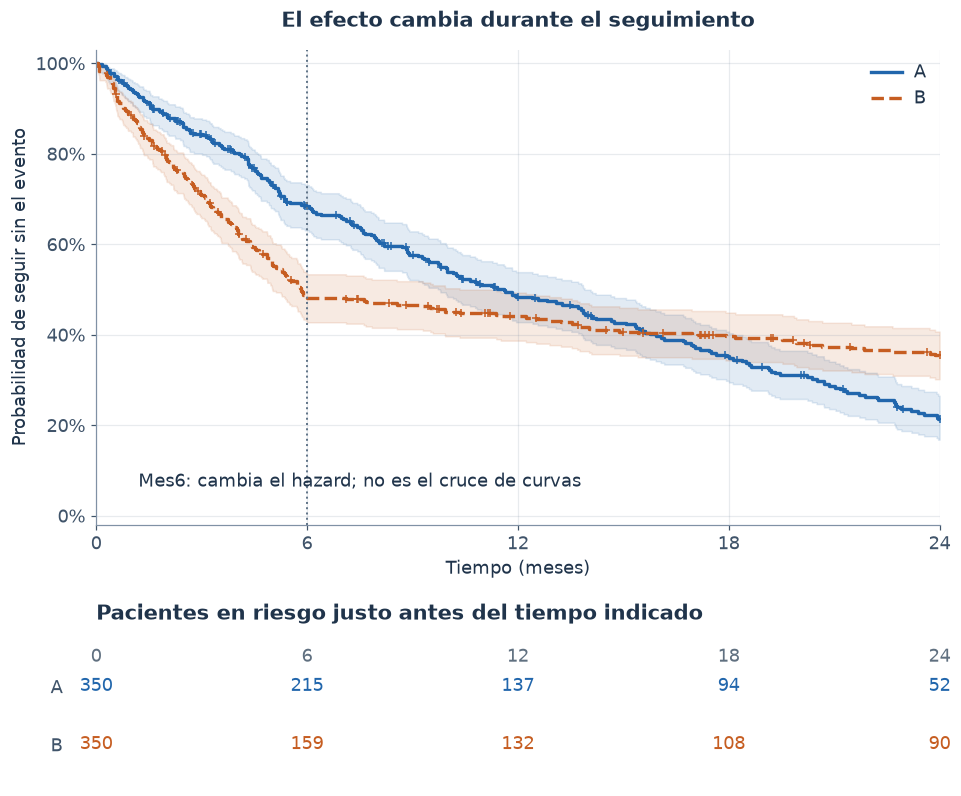

*Figura 03_curvas_cruzadas. B tiene más hazard al inicio y menos después; un HR constante resume mal este mecanismo.*

Horizonte (meses),RMST A (meses),RMST B (meses),Diferencia B−A (meses)
12,8.518,7.091,-1.427
24,12.758,11.823,-0.936


*Tabla 03_rmst. 24 meses: horizonte principal; 12 meses: contraste docente secundario del efecto del horizonte, no selección del más favorable.*

Diferencia,IC95 inferior,IC95 superior,p log-rank global
RMST B−A a 24 meses,-2.512,0.356,"0,813"


*Tabla 03_rmst_precision. IC percentil, 300 remuestras por grupo; semilla 1202. RMST no requiere HR constante, pero sí supuestos sobre censura.*

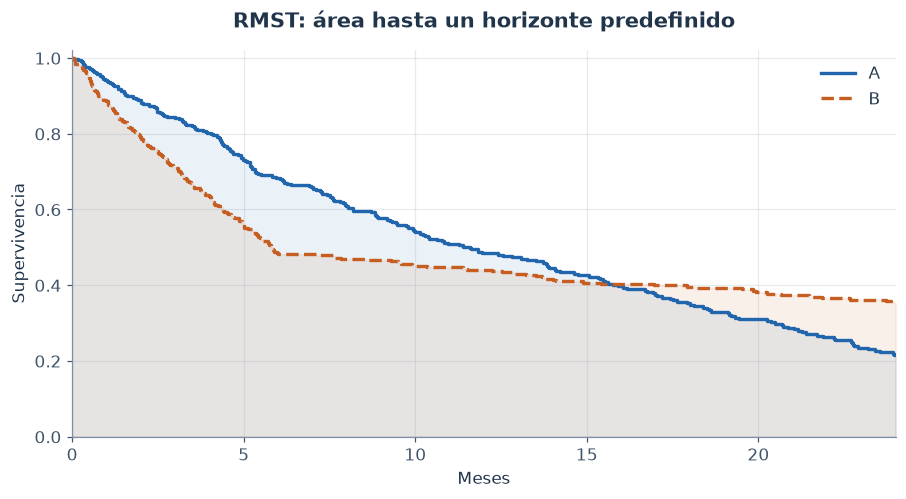

*Figura 03_area_rmst. Área restringida a 24 meses; no extrapola la cola de la curva.*

In [6]:
BLOQUE='03-01'
PDF_REF='2.8.1'
dcr=simular(1201,n=350,hA=.06,hB=.12,cambio=(6,.015))
contexto('Curvas cruzadas','Muerte después de cirugía','meses','Simulación de hazards por tramos',semilla=1201,N=len(dcr),cambio_mes=6,horizonte_RMST=24,semilla_bootstrap=1202)
datos(dcr,'03_datos_cruce')
fig,kcr=km_grupos(dcr,'El efecto cambia durante el seguimiento','meses',ticks=[0,6,12,18,24])
fig.axes[0].axvline(6,color='#62768A',ls=':',lw=1.3);fig.axes[0].text(.05,.08,'Mes6: cambia el hazard; no es el cruce de curvas',transform=fig.axes[0].transAxes,fontsize=10);figura(fig,'03_curvas_cruzadas','B tiene más hazard al inicio y menos después; un HR constante resume mal este mecanismo.')
aa=dcr.loc[dcr.grupo.eq('A')];bb=dcr.loc[dcr.grupo.eq('B')]
lrcr=logrank_test(aa.tiempo,bb.tiempo,aa.evento,bb.evento)
filas=[]
for tau in [12,24]:
    va=rmst_empirico(aa.tiempo,aa.evento,tau);vb=rmst_empirico(bb.tiempo,bb.evento,tau)
    assert np.isclose(va,restricted_mean_survival_time(kcr['A'],t=tau))
    filas.append({'Horizonte (meses)':tau,'RMST A (meses)':va,'RMST B (meses)':vb,'Diferencia B−A (meses)':vb-va})
rng=np.random.default_rng(1202);boot=[]
for _ in range(300):
    a=aa.iloc[rng.integers(0,len(aa),len(aa))];c=bb.iloc[rng.integers(0,len(bb),len(bb))]
    boot.append(rmst_empirico(c.tiempo,c.evento,24)-rmst_empirico(a.tiempo,a.evento,24))
lim=np.quantile(boot,[.025,.975]);tabla(pd.DataFrame(filas),'03_rmst','24 meses: horizonte principal; 12 meses: contraste docente secundario del efecto del horizonte, no selección del más favorable.')
tabla(pd.DataFrame({'Diferencia':['RMST B−A a 24 meses'],'IC95 inferior':[lim[0]],'IC95 superior':[lim[1]],'p log-rank global':[lrcr.p_value]}),'03_rmst_precision','IC percentil, 300 remuestras por grupo; semilla 1202. RMST no requiere HR constante, pero sí supuestos sobre censura.')
fig,ax=plt.subplots(figsize=(8.5,4.8))
for j,(g,k) in enumerate(kcr.items()):
    t=k.survival_function_.index.to_numpy();y=k.survival_function_.iloc[:,0].to_numpy()
    ax.step(t,y,where='post',label=g,color=COLORES[j],ls=ESTILOS[j]);ax.fill_between(t,0,y,step='post',alpha=.09,color=COLORES[j])
ax.set(title='RMST: área hasta un horizonte predefinido',xlabel='Meses',ylabel='Supervivencia',xlim=(0,24),ylim=(0,1.02));ax.legend();fig.tight_layout()
figura(fig,'03_area_rmst','Área restringida a 24 meses; no extrapola la cola de la curva.')

### 👀 Dónde mirar e interpretar
Compara dirección a 12 y 24; el área no extrapola el seguimiento. El IC se aproxima por remuestreo de pacientes.

### 📝 Tu respuesta
¿Sería correcto escoger después el horizonte más favorable?

Escribe aquí: …

<details><summary>Orientación: abre después de responder</summary>

No; cambiaría la pregunta según resultados. Declara horizonte y precisión, y describe el patrón temporal.

</details>

<a id="03-02"></a>
## 03-02 · Cambiar el evento: muerte, progresión y PFS

**Puente al PDF:** [apartado 2.8.2](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-2-8-2). En Colab puedes localizarlo por su número.

**Pregunta clínica.** ¿Estar vivo equivale a estar libre de progresión?

**Antes de ejecutar.** Mismos pacientes; cambia qué suceso termina la espera.

**Acción.** Pulsa ▶ en las celdas siguientes. No necesitas cambiar el código.

**PFS**, supervivencia libre de progresión, termina en la primera progresión o muerte. **OS**, supervivencia global, termina en muerte. Progresión sola es otra pregunta; no se obtiene simplemente llamando PFS a esa curva.

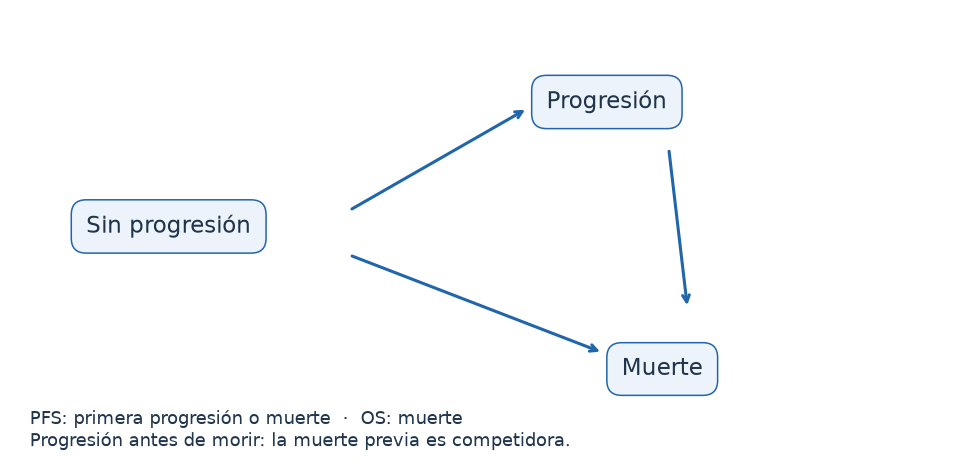

*Figura 03_estados_eventos. Esquema: para progresión como primer evento, morir sin progresión impide observarla; para PFS ambas vías son evento.*

In [7]:
BLOQUE='03-02'
PDF_REF='2.8.2'
contexto('Estados oncológicos','Progresión y muerte','No aplica','Esquema conceptual; no estimación de probabilidades')
fig,ax=plt.subplots(figsize=(9,4.5));ax.axis('off')
for xy,label in [((.08,.5),'Sin progresión'),((.57,.78),'Progresión'),((.65,.18),'Muerte')]:
    ax.text(*xy,label,fontsize=15,transform=ax.transAxes,bbox=dict(boxstyle='round,pad=.65',fc='#edf3fa',ec=AZUL))
for start,end in [((.36,.55),(.55,.78)),((.36,.45),(.63,.23)),((.70,.69),(.72,.33))]:
    ax.annotate('',xy=end,xytext=start,xycoords='axes fraction',arrowprops=dict(arrowstyle='->',lw=2,color=AZUL))
ax.text(.02,.02,'PFS: primera progresión o muerte  ·  OS: muerte\nProgresión antes de morir: la muerte previa es competidora.',transform=ax.transAxes,fontsize=12)
figura(fig,'03_estados_eventos','Esquema: para progresión como primer evento, morir sin progresión impide observarla; para PFS ambas vías son evento.')

**Tiempo cero del caso oncológico:** inicio del tratamiento. La unidad es el mes. El ejemplo posterior de alta comienza en el ingreso y usa días.

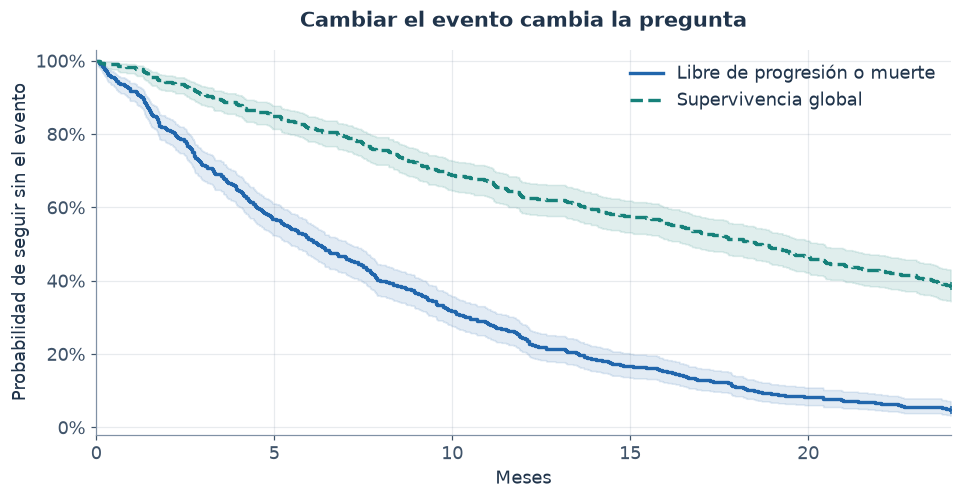

*Figura 03_evento_compuesto. Mismos pacientes: supervivencia libre de progresión incluye muerte; no debe confundirse con progresión sola censurando muertes.*

In [8]:
BLOQUE='03-02'
PDF_REF='2.8.2'
contexto('Compuesto progresión o muerte','Progresión o muerte; comparación con muerte sola','meses desde el inicio del tratamiento oncológico','Simulación multestado sencilla: la muerte puede ocurrir antes o después de progresión',semilla=1601,N=500)
display(Markdown('**Tiempo cero del caso oncológico:** inicio del tratamiento. La unidad es el mes. El ejemplo posterior de alta comienza en el ingreso y usa días.'))
rng=np.random.default_rng(1601);tp=rng.exponential(15,500);td=rng.exponential(24,500);c=24.
compuesto=np.minimum(tp,td)
pfs=KaplanMeierFitter(label='Libre de progresión o muerte').fit(np.minimum(compuesto,c),compuesto<=c)
os=KaplanMeierFitter(label='Supervivencia global').fit(np.minimum(td,c),td<=c)
fig,ax=plt.subplots(figsize=(9,4.8));curva(ax,pfs,AZUL);curva(ax,os,VERDE,'--')
ax.set(title='Cambiar el evento cambia la pregunta',xlabel='Meses',xlim=(0,24));ax.legend();fig.tight_layout()
figura(fig,'03_evento_compuesto','Mismos pacientes: supervivencia libre de progresión incluye muerte; no debe confundirse con progresión sola censurando muertes.')
datos(pd.DataFrame({'id':range(500),'progresion_latente':tp,'muerte_latente':td,'corte':c}),'03_datos_compuesto')

### 👀 Dónde mirar e interpretar
Una persona viva con progresión ya ha tenido evento dePFS.

### 📝 Tu respuesta
¿Cómo puede bajar PFS antes queOS?

Escribe aquí: …

<details><summary>Orientación: abre después de responder</summary>

Porque progresión también termina PFS. La muerte previa cuenta como evento enPFS, no como censura.

</details>

<a id="03-03"></a>
## 03-03 · Recaída con muerte competidora: incidencia acumulada

**Puente al PDF:** [apartado 2.8.3](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-2-8-3). En Colab puedes localizarlo por su número.

**Pregunta clínica.** ¿Cómo estimas recaída si algunos pacientes mueren antes?

**Antes de ejecutar.** La muerte previa impide observar la recaída: es un evento competidor.

**Acción.** Pulsa ▶ en las celdas siguientes. No necesitas cambiar el código.

La **incidencia acumulada** estima la probabilidad de la causa en presencia de competidores. Aalen–Johansen tiene en cuenta las transiciones observadas. Censurar muertes competidoras en 1−KM produce otra cantidad; no es la probabilidad real de recaída en presencia de muerte.

**Tiempo cero:** inicio del seguimiento posquirúrgico. La unidad es el mes.

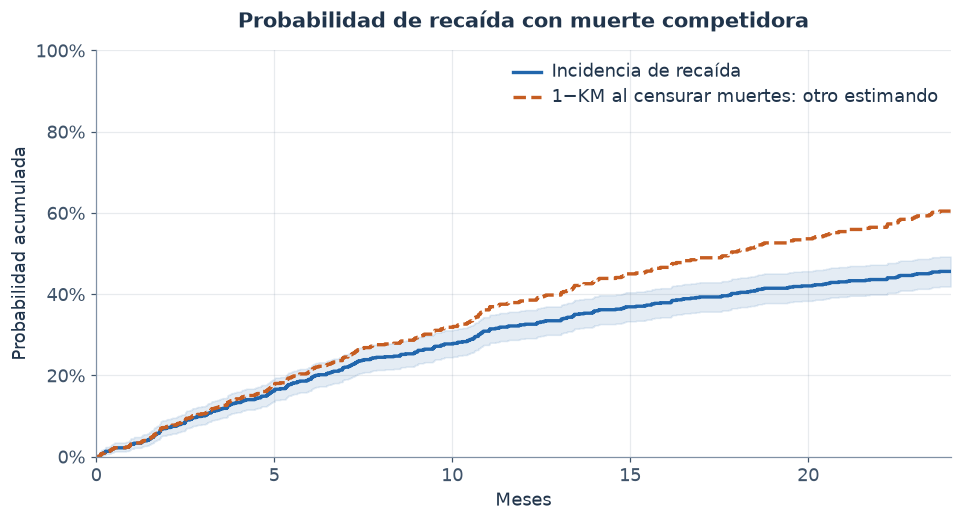

*Figura 03_incidencia_competitiva. La incidencia acumulada conserva el efecto de la muerte competidora. La línea naranja no estima la misma probabilidad.*

Medida,Estimación a 24 meses
Incidencia recaída,0.456
Incidencia muerte previa,0.356
1−KM recaída con muertes censuradas,0.604


*Tabla 03_competitivos_resultados. Las dos incidencias corresponden a primeros eventos mutuamente excluyentes; su suma no supera 1.*

In [9]:
BLOQUE='03-03'
PDF_REF='2.8.3'
contexto('Recurrencia y muerte competidora','Primera recaída; muerte previa como competidor','meses desde el inicio del seguimiento posquirúrgico','Simulación de dos tiempos latentes independientes',semilla=1501,N=700)
display(Markdown('**Tiempo cero:** inicio del seguimiento posquirúrgico. La unidad es el mes.'))
rng=np.random.default_rng(1501);tr=rng.exponential(25,700);tm=rng.exponential(30,700);c=np.full(700,24.)
t=np.minimum(np.minimum(tr,tm),c);estado=np.where((tr<tm)&(tr<=c),1,np.where((tm<tr)&(tm<=c),2,0))
competitivo=pd.DataFrame({'id':range(700),'tiempo':t,'estado':estado});datos(competitivo,'03_datos_competitivos')
aj=AalenJohansenFitter(seed=1502).fit(t,estado,event_of_interest=1,label='Incidencia de recaída')
ajm=AalenJohansenFitter(seed=1502,calculate_variance=False).fit(t,estado,event_of_interest=2,label='Incidencia de muerte previa')
neto=KaplanMeierFitter(label='1−KM: riesgo neto, no incidencia real').fit(t,estado==1)
fig,ax=plt.subplots(figsize=(9,5))
aj.plot_cumulative_density(ax=ax,ci_show=True,ci_alpha=.12,color=AZUL)
ax.step(neto.survival_function_.index,1-neto.survival_function_.iloc[:,0],where='post',color=NARANJA,ls='--',label='1−KM al censurar muertes: otro estimando')
ax.set(title='Probabilidad de recaída con muerte competidora',xlabel='Meses',ylabel='Probabilidad acumulada',xlim=(0,24),ylim=(0,1));ax.yaxis.set_major_formatter(PercentFormatter(1));ax.legend(fontsize=9);fig.tight_layout()
figura(fig,'03_incidencia_competitiva','La incidencia acumulada conserva el efecto de la muerte competidora. La línea naranja no estima la misma probabilidad.')
cifras=pd.DataFrame({'Medida':['Incidencia recaída','Incidencia muerte previa','1−KM recaída con muertes censuradas'],
    'Estimación a 24 meses':[float(aj.cumulative_density_.iloc[-1,0]),float(ajm.cumulative_density_.iloc[-1,0]),1-float(neto.predict(24))]})
tabla(cifras,'03_competitivos_resultados','Las dos incidencias corresponden a primeros eventos mutuamente excluyentes; su suma no supera 1.')
assert cifras.iloc[:2,1].sum()<=1+1e-12

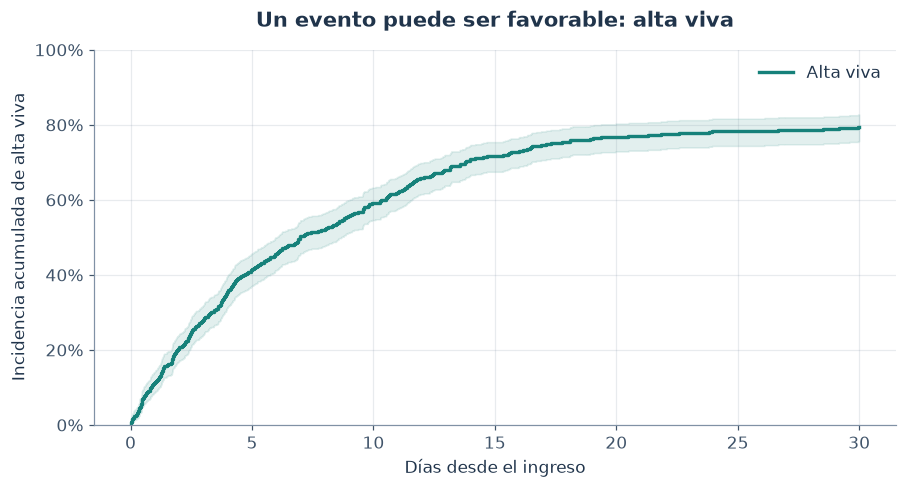

*Figura 03_alta_evento_favorable. Mayor incidencia de alta viva tiene otra lectura clínica que mayor incidencia de muerte. No basta interpretar HR<1 como bueno en todos los casos.*

In [10]:
BLOQUE='03-03'
PDF_REF='2.8.3'
contexto('Alta hospitalaria viva','Alta viva; muerte previa competidora','días desde ingreso','Simulación de dos eventos competidores',semilla=1602,N=500)
rng=np.random.default_rng(1602);alta=rng.exponential(9,500);muerte=rng.exponential(35,500);T=np.minimum(np.minimum(alta,muerte),30)
estado_alta=np.where((alta<muerte)&(alta<=30),1,np.where((muerte<alta)&(muerte<=30),2,0))
ajalta=AalenJohansenFitter(seed=1603).fit(T,estado_alta,event_of_interest=1,label='Alta viva')
fig,ax=plt.subplots(figsize=(8.5,4.7));ajalta.plot_cumulative_density(ax=ax,color=VERDE,ci_alpha=.12)
ax.set(title='Un evento puede ser favorable: alta viva',xlabel='Días desde el ingreso',ylabel='Incidencia acumulada de alta viva',ylim=(0,1));ax.yaxis.set_major_formatter(PercentFormatter(1));fig.tight_layout()
figura(fig,'03_alta_evento_favorable','Mayor incidencia de alta viva tiene otra lectura clínica que mayor incidencia de muerte. No basta interpretar HR<1 como bueno en todos los casos.')
datos(pd.DataFrame({'id':range(500),'tiempo':T,'estado':estado_alta}),'03_datos_alta')

### 📖 Paper real · Austin
[10.1161/CIRCULATIONAHA.115.017719](https://www.ahajournals.org/doi/pdf/10.1161/circulationaha.115.017719)

Tutorial con aplicación a pacientes hospitalizados por insuficiencia cardíaca. Para probabilidad de una causa con competidores se usa incidencia acumulada; 1−KM no estima la misma cantidad.

**Qué mirar:** Resumen; Circulation 2016;133:601–609. Se enseña con simulación propia, no cifras de la cohorte publicada.

**Pregunta:** ¿Morir antes de recaer es una pérdida de seguimiento corriente?

<details><summary>Orientación</summary>

Impide observar recaída; cambia el estimando de probabilidad.

</details>

*Texto primario indexado; resumen y primera página. Ejemplo histórico; no recomendación terapéutica actual.*

### 👀 Dónde mirar e interpretar
Recaída y alta viva son eventos con distintas direcciones clínicas. Distingue evento 0=censura y causas 1/2.

### 📝 Tu respuesta
¿Por qué una mayor incidencia no es siempre peor?

Escribe aquí: …

<details><summary>Orientación: abre después de responder</summary>

Depende del evento: mayor alta viva puede ser favorable; mayor muerte, desfavorable.

</details>

<a id="03-04"></a>
## 03-04 · Censura: distinguir cantidad y mecanismo

**Puente al PDF:** [apartado 2.8.4](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-2-8-4). En Colab puedes localizarlo por su número.

**Pregunta clínica.** ¿Importa solo cuántos pacientes perdemos o también a quiénes?

**Antes de ejecutar.** Mismos 2000 tiempos latentes y tres mecanismos; semillas y parámetros fijados previamente.

**Acción.** Pulsa ▶ en las celdas siguientes. No necesitas cambiar el código.

Compara censura **administrativa**, **independiente/aleatoria** y **relacionada con el pronóstico**. La última usa un futuro conocido solo por el simulador para mostrar un mecanismo; no es información disponible en consulta. Los porcentajes esperados se calibraron al 35% antes de generar la muestra docente. No se escoge la semilla mirando las curvas.

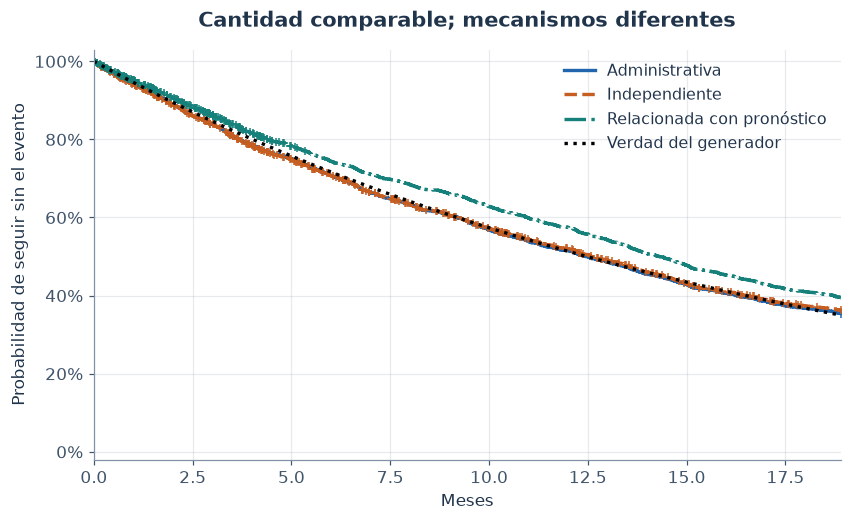

*Figura 03_censura_informativa. Escenario v2; curvas sin IC para comparar mecanismos. No confundir igual cantidad con igual calendario. La curva verdadera solo se conoce por simulación.*

Mecanismo,N,Eventos,Censuras,Censura (%),Mediana tiempo de censura (meses),S12
Administrativa,2000,1292,708,35.400,18.897,0.516
Independiente,2000,1305,695,34.750,24.000,0.522
Relacionada con pronóstico,2000,1290,710,35.500,24.000,0.575


*Tabla 03_recuento_perdidas. Cantidades reales de esta semilla; no se han igualado recortando personas. Comparación S12 dentro del soporte de los tres mecanismos.*

In [11]:
BLOQUE='03-04'
PDF_REF='2.8.4'
from scipy.optimize import brentq
MEDIA=18.0
OBJETIVO=.35
CORTE=24.0
ADMIN=-MEDIA*np.log(OBJETIVO)
TASA=brentq(lambda h:1-(1/MEDIA)/(1/MEDIA+h)*(1-np.exp(-(1/MEDIA+h)*CORTE))-OBJETIVO,1e-8,1)
PROB=(OBJETIVO-np.exp(-CORTE/MEDIA))/(1-np.exp(-12/MEDIA))
SEMILLA_DOCENTE=1402
N_DOCENTE=2000
SEMILLAS_VALIDACION=list(range(24092100,24092200))

def generar(seed,n=N_DOCENTE):
    rng=np.random.default_rng(seed)
    real=rng.exponential(MEDIA,n)
    censuras={'Administrativa':np.full(n,ADMIN),
              'Independiente':np.minimum(rng.exponential(1/TASA,n),CORTE),
              'Relacionada con pronóstico':np.where((real<12)&(rng.random(n)<PROB),.45*real,CORTE)}
    return real,censuras


real,cs=generar(SEMILLA_DOCENTE)
contexto('Censura tres mecanismos v2','Muerte después de cirugía','meses','Simulación de verdad conocida; calibración analítica previa',N=N_DOCENTE,semilla=SEMILLA_DOCENTE,objetivo_censura=OBJETIVO,corte_administrativo=ADMIN,tasa_independiente=TASA,probabilidad_pronostica=PROB)
fig,ax=plt.subplots(figsize=(8,5));filas=[];datos_c=pd.DataFrame({'id':range(N_DOCENTE),'tiempo_latente':real})
for j,(name,c) in enumerate(cs.items()):
    tiempo=np.minimum(real,c);evento=real<=c;k=KaplanMeierFitter(label=name).fit(tiempo,evento)
    curva(ax,k,COLORES[j],ESTILOS[j],ci=False)
    filas.append({'Mecanismo':name,'N':len(real),'Eventos':int(evento.sum()),'Censuras':int((~evento).sum()),'Censura (%)':100*(~evento).mean(),'Mediana tiempo de censura (meses)':float(np.median(tiempo[~evento])),'S12':float(k.predict(12))})
    datos_c[f'{j}_censura']=c;datos_c[f'{j}_tiempo']=tiempo;datos_c[f'{j}_evento']=evento.astype(int)
    assert np.all(tiempo==np.minimum(real,c))
tt=np.linspace(0,ADMIN,200);ax.plot(tt,np.exp(-tt/MEDIA),':',color='black',label='Verdad del generador')
ax.set(xlim=(0,ADMIN),xlabel='Meses',title='Cantidad comparable; mecanismos diferentes');ax.legend(fontsize=10);fig.tight_layout()
figura(fig,'03_censura_informativa','Escenario v2; curvas sin IC para comparar mecanismos. No confundir igual cantidad con igual calendario. La curva verdadera solo se conoce por simulación.')
tabla(pd.DataFrame(filas),'03_recuento_perdidas','Cantidades reales de esta semilla; no se han igualado recortando personas. Comparación S12 dentro del soporte de los tres mecanismos.')
datos(datos_c,'03_datos_censura')

### 👀 Dónde mirar e interpretar
Compara porcentaje, momento de censura y distancia a la verdad.100 repeticiones independientes dieron censura media 34.8–34.9%; el sesgo medio informativo a 12 meses fue alrededor de 5.3 puntos. Una muestra no garantiza el mismo orden.

### 📝 Tu respuesta
¿Basta un porcentaje bajo para descartar sesgo?

Escribe aquí: …

<details><summary>Orientación: abre después de responder</summary>

No: importan mecanismo, motivos y relación con pronóstico; KM no recupera lo ocurrido después de perder contacto.

</details>

<a id="03-05"></a>
## 03-05 · Entrada tardía: desde cuándo se pertenece al riesgo

**Puente al PDF:** [apartado 2.8.5](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-2-8-5). En Colab puedes localizarlo por su número.

**Pregunta clínica.** ¿Desde cuándo puede una persona formar parte del riesgo observado?

**Antes de ejecutar.** Diagnóstico y entrada al estudio pueden ocurrir en fechas diferentes.

**Acción.** Pulsa ▶ en las celdas siguientes. No necesitas cambiar el código.

**Entrada tardía:** se observa a alguien desde un momento posterior al origen temporal y se requiere que haya sobrevivido hasta entrar. El conjunto en riesgo debe incorporar su fecha de entrada. No es censura izquierda.

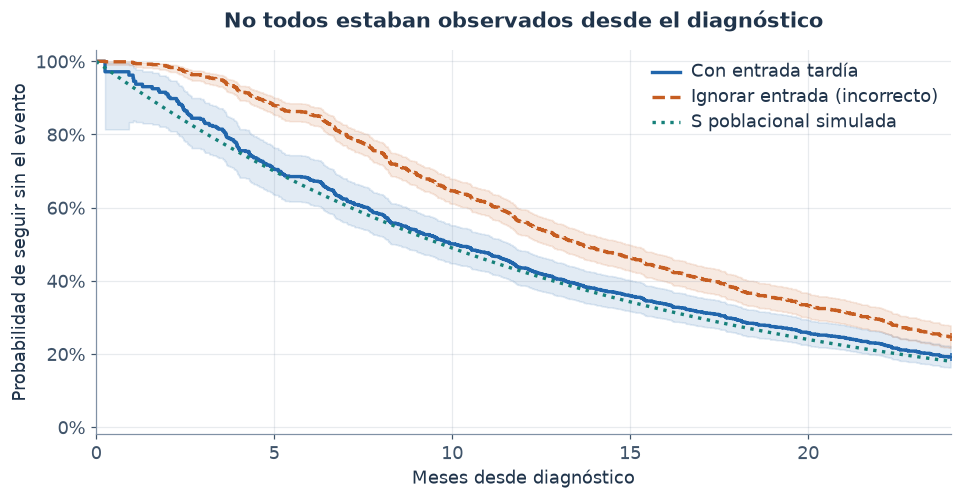

*Figura 03_entrada_tardia. La entrada tardía requiere ajustar los conjuntos de riesgo; estimación desde el inicio de observación apoyado por datos, bajo entrada independiente.*

In [12]:
BLOQUE='03-05'
PDF_REF='2.8.5'
contexto('Entrada tardía','Muerte desde diagnóstico','meses','Simulación con entrada independiente y selección de supervivientes a la entrada',semilla=1901,N_potencial=1000)
rng=np.random.default_rng(1901);T=rng.exponential(14,1000);entrada=rng.uniform(0,8,1000);mask=T>entrada
D=np.minimum(T[mask],24);E=T[mask]<=24;L=entrada[mask]
correcto=KaplanMeierFitter(label='Con entrada tardía').fit(D,E,entry=L)
incorrecto=KaplanMeierFitter(label='Ignorar entrada (incorrecto)').fit(D,E)
fig,ax=plt.subplots(figsize=(9,4.8));curva(ax,correcto,AZUL);curva(ax,incorrecto,NARANJA,'--')
tt=np.linspace(0,24,100);ax.plot(tt,np.exp(-tt/14),':',color=VERDE,label='S poblacional simulada')
ax.set(title='No todos estaban observados desde el diagnóstico',xlabel='Meses desde diagnóstico',xlim=(0,24));ax.legend(fontsize=9);fig.tight_layout()
figura(fig,'03_entrada_tardia','La entrada tardía requiere ajustar los conjuntos de riesgo; estimación desde el inicio de observación apoyado por datos, bajo entrada independiente.')
datos(pd.DataFrame({'inicio':L,'fin':D,'evento':E.astype(int)}),'03_datos_entrada')

### 👀 Dónde mirar e interpretar
El análisis correcto usa inicio y fin; no atribuye tiempo observado anterior a entrada.

### 📝 Tu respuesta
¿Una persona que entra al mes 4 estaba observada en el mes 2?

Escribe aquí: …

<details><summary>Orientación: abre después de responder</summary>

No. Se ajusta el riesgo desde entrada y se necesitan supuestos sobre ese proceso de entrada.

</details>

<a id="03-06"></a>
## 03-06 · Trasplante, intervalos y tiempo inmortal

**Puente al PDF:** [apartado 2.8.6](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-2-8-6). En Colab puedes localizarlo por su número.

**Pregunta clínica.** ¿Puede alguien contar como trasplantado antes de recibir el trasplante?

**Antes de ejecutar.** Conserva el identificador; la exposición cambia dentro de una historia.

**Acción.** Pulsa ▶ en las celdas siguientes. No necesitas cambiar el código.

El **tiempo inmortal** aparece al atribuir desde el comienzo una exposición que exige sobrevivir para recibirla después. Los **intervalos** permiten separar tiempo sin y con exposición. El evento 0 en un cambio de tramo no indica que se haya perdido al paciente.

Análisis,HR,IC95 inferior,IC95 superior
Codificación incorrecta: alguna vez,0.030,0.021,0.041
Covariable cambiante: intervalos,0.929,0.639,1.351


*Tabla 03_tiempo_inmortal_resultados. El primer análisis es deliberadamente incorrecto y solo se muestra para aprender a detectar el sesgo. HR real=1 por construcción.*

id,inicio,fin,evento,trasplante
0,0.000,2.994,1,0
1,0.000,2.637,0,0
1,2.637,12.630,1,1
2,0.000,4.218,1,0
3,0.000,3.934,1,0
4,0.000,2.744,0,0
4,2.744,18.000,0,1
5,0.000,2.782,0,0
5,2.782,3.596,1,1


*Tabla 03_intervalos_ejemplo. Dos filas pueden representar una persona: antes y después del trasplante.*

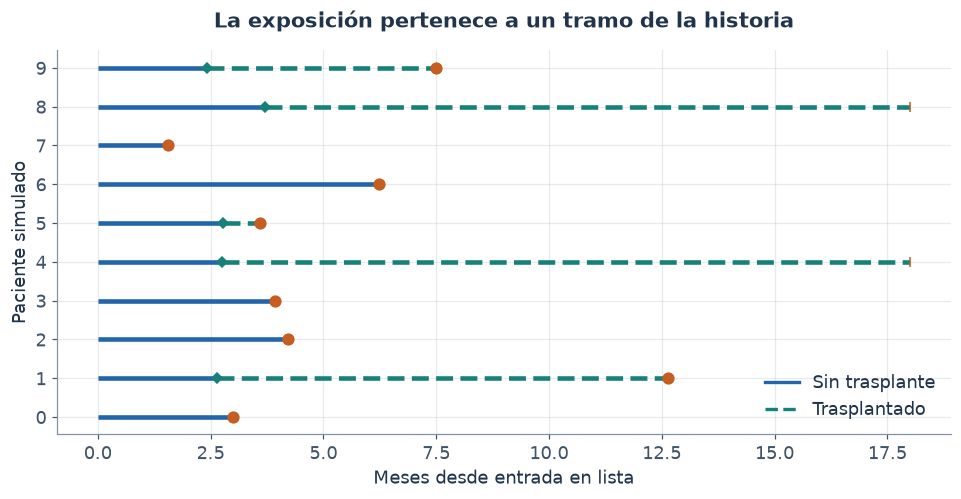

*Figura 03_trasplante_intervalos. Rombo: cambio de exposición; círculo final: muerte; barra final: censura. No hay efecto real de tratamiento en esta simulación.*

In [13]:
BLOQUE='03-06'
PDF_REF='2.8.6'
contexto('Trasplante y tiempo inmortal','Muerte desde entrada en lista','meses','Simulación sin efecto causal del trasplante; fecha programada independiente del tiempo de muerte',semilla=1701,N=600)
rng=np.random.default_rng(1701);muerte=rng.exponential(15,600);plan=rng.uniform(2,8,600);fin=np.minimum(muerte,18);evento=(muerte<=18).astype(int)
recibio=plan<fin
ingenuo=pd.DataFrame({'id':range(600),'tiempo':fin,'evento':evento,'alguna_vez':recibio.astype(int)})
filas=[]
for i in range(600):
    if recibio[i]:filas.extend([{'id':i,'inicio':0.,'fin':plan[i],'evento':0,'trasplante':0},
        {'id':i,'inicio':plan[i],'fin':fin[i],'evento':evento[i],'trasplante':1}])
    else:filas.append({'id':i,'inicio':0.,'fin':fin[i],'evento':evento[i],'trasplante':0})
intervalos=pd.DataFrame(filas);assert (intervalos.fin>intervalos.inicio).all()
mal=CoxPHFitter().fit(ingenuo[['tiempo','evento','alguna_vez']],'tiempo','evento')
bien=CoxTimeVaryingFitter().fit(intervalos,id_col='id',start_col='inicio',stop_col='fin',event_col='evento')
filas=[]
for label,m,var in [('Codificación incorrecta: alguna vez',mal,'alguna_vez'),('Covariable cambiante: intervalos',bien,'trasplante')]:
    s=m.summary.loc[var];filas.append({'Análisis':label,'HR':s['exp(coef)'],'IC95 inferior':s['exp(coef) lower 95%'],'IC95 superior':s['exp(coef) upper 95%']})
tabla(pd.DataFrame(filas),'03_tiempo_inmortal_resultados','El primer análisis es deliberadamente incorrecto y solo se muestra para aprender a detectar el sesgo. HR real=1 por construcción.')
tabla(intervalos.loc[intervalos.id<6],'03_intervalos_ejemplo','Dos filas pueden representar una persona: antes y después del trasplante.')
fig,ax=plt.subplots(figsize=(9,4.8))
for i in range(10):
    ax.hlines(i,0,min(plan[i],fin[i]),color=AZUL,lw=3)
    if recibio[i]:ax.hlines(i,plan[i],fin[i],color=VERDE,lw=3,ls='--');ax.plot(plan[i],i,'D',color=VERDE,ms=5)
    ax.plot(fin[i],i,'o' if evento[i] else '|',color=NARANJA,ms=7)
ax.plot([],[],color=AZUL,label='Sin trasplante');ax.plot([],[],color=VERDE,ls='--',label='Trasplantado')
ax.set(title='La exposición pertenece a un tramo de la historia',xlabel='Meses desde entrada en lista',ylabel='Paciente simulado',yticks=range(10));ax.legend();fig.tight_layout()
figura(fig,'03_trasplante_intervalos','Rombo: cambio de exposición; círculo final: muerte; barra final: censura. No hay efecto real de tratamiento en esta simulación.')
datos(intervalos,'03_datos_intervalos');datos(ingenuo,'03_datos_codificacion_incorrecta')

In [14]:
BLOQUE='03-06'
PDF_REF='2.8.6'
contexto('Una historia con trasplante','Muerte desde lista de espera','meses',
         'Selección de una historia ya generada en 03-06; no nueva simulación',semilla=1701)
iv=pd.read_csv(OUT/'03_intervalos_ejemplo.csv')
ident=iv.groupby('id').size().loc[lambda s:s>1].index[0]
tabla(iv.loc[iv.id==ident],'03_historia_intervalos','Mismo identificador en dos intervalos; evento=0 al cambiar exposición no es una pérdida de seguimiento.')

id,inicio,fin,evento,trasplante
1,0.000,2.637,0,0
1,2.637,12.630,1,1


*Tabla 03_historia_intervalos. Mismo identificador en dos intervalos; evento=0 al cambiar exposición no es una pérdida de seguimiento.*

### 📖 Paper real · CrowleyHu
[10.1080/01621459.1977.10479903](https://doi.org/10.1080/01621459.1977.10479903)

Análisis observacional del programa de trasplante cardíaco de Stanford. Contexto histórico de exposición que cambia e intervalos start/stop/event; no se atribuyen HR ni conclusiones no consultadas.

**Qué mirar:** JASA1977;72:27–36; https://stat.ethz.ch/R-manual/R-devel/library/survival/html/heart.html. Sin resultados numéricos del artículo; simulación docente independiente.

**Pregunta:** ¿Desde cuándo debe marcarse la exposición al trasplante?

<details><summary>Orientación</summary>

Desde el trasplante; los meses previos conservan exposición 0 y el mismo identificador.

</details>

*Metadatos editoriales Crossref y documentación primaria survival::heart; texto completo no accesible 403. Ejemplo histórico; no recomendación terapéutica actual.*

### 👀 Dónde mirar e interpretar
Los dos modelos comparados usan codificaciones distintas. El primero es deliberadamente incorrecto.

### 📝 Tu respuesta
¿Dos filas con el mismo identificador son dos personas?

Escribe aquí: …

<details><summary>Orientación: abre después de responder</summary>

No. Antes y después del trasplante son tramos de una misma persona; en datos reales puede haber confusión dependiente del tiempo adicional.

</details>

<a id="03-07"></a>
## 03-07 · Transferencia a un segundo conjunto Open Data

**Puente al PDF:** [apartado 2.8.7](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-2-8-7). En Colab puedes localizarlo por su número.

**Pregunta clínica.** ¿Puedes transferir lo aprendido a otro conjunto clínico?

**Antes de ejecutar.** NCCTG lung: status 1=censura,2=muerte. No reutilices ciegamente la regla 0/1 decolon.

**Acción.** Pulsa ▶ en las celdas siguientes. No necesitas cambiar el código.

**Origen:** [survival::lung](https://stat.ethz.ch/R-manual/R-devel/library/survival/html/lung.html), alias `cancer`; copia pública fijada,228 pacientes con cáncer pulmonar avanzado. Tiempo en días desde el inicio registrado del seguimiento; no se presupone fecha de diagnóstico. Evento muerte. Horizonte365 días. Compara descriptivamente por sexo registrado; no es un tratamiento ni un efecto causal. [CSV de esta versión](https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/cc03c29690889dbe83089f5206e2422db8c3f71f/csv/survival/cancer.csv). Paquete survival: LGPL≥2; se conserva procedencia.

Código original,Significado,Evento analítico
1,Censura,0
2,Muerte,1


*Tabla 03_lung_codigos. Los códigos no son universales: se transforman usando el diccionario, no suposiciones.*

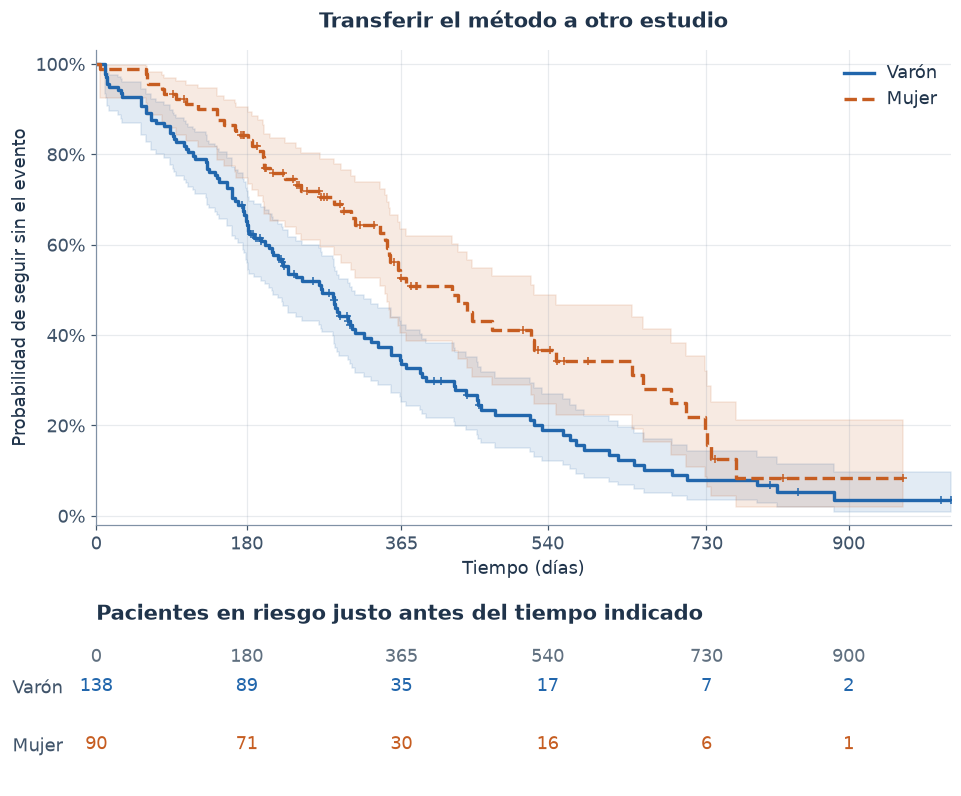

*Figura 03_lung_transferencia. Descripción por sexo registrado, sin interpretación causal. Datos reales históricos, no simulados.*

Grupo,N,Eventos,Censuras,Horizonte,S(t),IC95 inferior,IC95 superior,Mediana
Total,228,165,63,365,0.409,0.339,0.478,310.00
Varón,138,112,26,365,0.336,0.253,0.421,270.00
Mujer,90,53,37,365,0.526,0.404,0.635,426.00


*Tabla 03_lung_365. S365 e IC95% puntual. Selección del dataset y horizonte anterior a observar resultados; no búsqueda de significación.*

In [15]:
BLOQUE='03-07'
PDF_REF='2.8.7'
LUNG_B64='H4sIAAAAAAAC/2VZ244dNw5817e0gxZ1/5xBYGSDTeIg9iL5/K0qSi31BLHHk6MbRbKKRZ2/vv39x8fvX79fv/7x/cf149ffv17ff3z8+N/36+MX/Pr1n+vP//z09edvv/Df/3789ce368+PH/O3379+/PbTzx+/XX//+Om3b9+/h3ilK931sqvlK+K/cV/xxt/YyhUMo7kUjNaOsZujnGBWrlgClmJyxAdXqcc4x/KFZRiyq7S1ceW+hT8C1l+9J+58ayUP5dI7YCfD/xp+LKOwpt9XiQnD7WpX0sawyWi4Nk4dU+8AM3GlGvl51HD1tQkjYWAvi1xWkjZuGuy8Tg3YFKZWOqNyUFvjj2GnlAM2hmntuFLXapiKq7ZAq+tVS36Zhj+XpQDTsb5ZX4Nx+aqEiBXRzZUz+LNNLycLsdAhpbbXwbSj3rx6iPR9zDr3GZ9hiFjF6yS35hVhePULZnSa3W5uX5OuXfx83Qvn02vyaKnLo/hj9Ogd7Kbxvb8C3Z8EiorHHV+2LafFFmjc1TmcB364aW0u/9KDyW/Vspu1Y8aA4VM4J8lz5UlQZRJWxxRMrkuDq5utCV1pZsqzQvvlzMdyZgP2bhdSuOV3hvpfTPjC3XEkzevLt2lF7sbxhiMGJ6Rx74TzyHVeroWkC9kCn3bBJdOt1UljuQkk40iZaUBI/MiEXY+bn54YDCxPyOaSuDr3NcyrfwH8UmbQowf9VlSLojq0NaDtSZdeWPDb07XYXklnygdbG5RpXEhKux7lvrLWV8ew9cDcKdfQkACnsA73TA6JKTfSdgw2zhMRlgN/xZ11p6zF/WAtkg8o48r13knf/XZuezYmVdTt5F47Awf3ZPLaleW84nnprk9ACKAOrBHtuWz3+fWugM/gdme2rqPrRhNWAmrX4Lp2gqnS7bwZMZLu5+Y6FKtzJU0HBDLBhWNBdeWTownjSria3+uZMpmeC3Cj8eTiLrVPfJ9DYRK3VBwvB0uNUEx37s/h9zwcWKIn48yWFw5lGMYVxVw3Tifd69gWUGLAnNq6jJNEEvcoQdVFVtcTxY2pBtYpV/E8WwSCsYQUw8LOC8dki56eQMUecBSc1ZtbZZubzL0p3CcPcj4IQlnyJQVyIsAl4iXgH8LPOLuHKoeZPQh83apigrwWtbQ94XzcFnBojJ5futs+X07FZ1hUJz3sJI/Rhytv99TuRS5kNxzNQgeW6M7L03RVSQuYjzmm3M0r+VeW4dpD116lLG6fxxvARYWGGSgP94vzOSWTmVIAXyNLu1A8M2nsbACxNZMqKe44ewqazBsBviJKX7T55DCOV6wU8nwfJQem09UMWr0mt52cj2GVhOyUGl+MS17AyU1EJfjEM9sUUhzdcXNxhNfKB58mfIfGjJPlPa57i8iQ4122tofOH6/D34A+FuSrjbgg8hzdGK7QeWUnllJWmaTlxRHUdW4cBBLpbyd7VkJ0aZCoXMj59DlihpB0KiR8pPX5X4U89MqY9+ye2xokKjA5dNchOa568ayXIAzMDIqYtgrOmyKwgaitKaL5RCMNTCMMuU+uV6VfWByUimFIh1SXsuncfnjKDSIVyTleJYNzmLGDGSeNU+sBZBarHgaFJ9itOMfYA0STe8NgPGhl9DK+tS40xFDKCSvT7LW2gxdHY7608YI4U9lKGF0rpYSnyyfpIhHH4H1za85dxyD9AcmI39LUuhI/K9vIe5D0tFhpJmLc2qdFZROCjnBnlZApTfoOFtQuKhiVj+ij1FO2QUff+Xq0R1q2eSGJd5GmkuEyQIXqkg6+vTMQsmYc+iMaIjdulEPFZPhLGAxn7HiLhw816vim6sHgYA5mGxtEE2NcjltHOi0J+ZPvqziVy6EaYhSxxbLCtZxaXHbEKOC52s0vkMz9JTtM4qHf74KAFEGHAkGFwfux4Cm0F49nFS0ulV+3V8i8S0iuPDY+Mj+ibUw1kxjN4yiU1aUsVW6cm9d+qE0xX+KEoZKyUfLswBMQHbul1uv7dhRVEAZ0n816an67o5/E9kQnpo3xklzdDaRzjd1oOVPSx2fCm4ppyRtorrxIn8wME0rLo+XvU2xHdndVDOFpWw8wMvr0kLEzHbYblVmOb+9FogmwXs7P6I+RZKD8V4qw4iXZN2i8U0cHeUuSU5t6WbxnT01MJZYHG49gPY0rwE4yL/j2akVEJTgbQhd1SxVRCnSTLwsXkof9ApWnE8NR2ZAsGJXCV+2o7cj7RDGKYXnOF6s4ywtgcpBfgmfRLJDJVht3bE7T1GQlV2n1YEj5FeNM1izeLfmENBHP3hrwgxh8lh993CyNkUUpLlSlQ8172ebLQNZLyJ33k0R/0JMQGypu3tI+w0uHcAJXqfDVcvLlLcnCToJ8LXFcXpqJDRPhRfHMGHHzLV0IDkQ3S855AFt8qQPCFxPU5Ht53G56tC6yk6BnOaF/7UwBEQSixKSGKfnePdF+s4nFucWO+jl9KE3HVwxbajmujnpxF3dnhU2xLC+d0C/erHbbqq0/iV/4RjKLQnk6zbR7Ig5hylNDF2+0SXxFRSMJku+XGZrVBau4Oo+VGbn5k0+R12aFPjsySlXe2nsIpcRWhGM+OWEDaB2Yr8er98UpGJA3PJUvPX3rsuk1U/kNjCkL2jDXF5uZNSEheavqrWh119spX7gBO1ZGOR68NHObuU+yY/JVz007qNGLPTFPbZkXNT/xSRyVskt6Z8lvBHZ6MlDg1lkWazwg3JKYW/oZDFjWW8JmJ2+EojcUSbKlvqRQV9sb1csmkWZ5mPPo9KJgH0fbcmU81YEU1ZSCSchQd/3YwD4TTlK9YuMeF72eJ9CEKoBIgG+GPnrkqOYi9nsTXd1bMJeavzf1meoHTwZmYJwPEhsiM40Ib05EDMei4B0EzsDpffrw3vBcM6b60eVNmZrGv4qEXhKT09DtJdI+vQNgQma2mwrwiwcpwWPXm5Nn8myvDifSRhfLevfKL/mzTFTd7M/zhc0uiM8nxDpbBWjnKWz3Q4JEDNDGJoNM/K7RdZEJ30L1gmK9rjr6ehPHFuw0MNgeRb+uyOaXInWoEivbi51CyusZSjgZJcWtI8bz+h0IMqqkssF6NLCIMztAU6DPrmDMKzKLvOPwLdqnl02mMZKZbQemSGnU9Im14MYhSJtyrp5Fl2ge4iBnPDt75KFSZ5SLvGBZL6tL/kNA+QS2w5dTaj74mA4EFqVhZgmarybzQZpbF4wnt/5e1n9+jbLbVbT5NwsnGCqlDCYUlXPpmvqCe9Z3EIZWJFGsl10YHIjUhwxBXkLpXhmONpLvLSQBdZnlPt7//EmXM9SDGCXR0fL51mw/2BulTSHzNZvv8JJXppSq98vkrlJEbU+JIoe1TzxP47x1EQrX0WNnJk+QhPZCkxe6VMATfCbgeINRy+tbCC6tKlI2gX/uzUTEOz/6Dxqg3XM8L/dFG/j7QD/6F0dm17OqRTW87oT2tAeUAUASLqfy4yw9a1h/nhDRe5j3Hsz8+P4SRQIO3jO9GZsYfr4N9bMI8Z2PrWVdBj4Cm2MCiZ4AWjtoRZZ5x0veWLzq+W7Jv6DhcxURcwux5fVcLXVu6Dz4zVT2x/TzOx71Hpjgz6A6u/SX8ZU19v+NS5JsVBwAAA=='
LUNG_SHA='4045e3fee76936bb8bd9312243d7b81b36ed224a12800fcef12e8a361883cfb6'

raw_l=gzip.decompress(base64.b64decode(LUNG_B64));assert hashlib.sha256(raw_l).hexdigest()==LUNG_SHA
lung=pd.read_csv(io.BytesIO(raw_l));assert len(lung)==228 and set(lung.status)=={1,2}
lung['tiempo']=lung.time;lung['evento']=(lung.status==2).astype(int);lung['grupo']=lung.sex.map({1:'Varón',2:'Mujer'})
assert lung[['tiempo','evento','grupo']].notna().all().all() and (lung.tiempo>0).all()
contexto('NCCTG lung real','Muerte por cualquier causa','días','survival::lung/cancer; copia pública con huella',N=228,eventos=int(lung.evento.sum()),sha256=LUNG_SHA)
tabla(pd.DataFrame({'Código original':[1,2],'Significado':['Censura','Muerte'],'Evento analítico':[0,1]}),'03_lung_codigos','Los códigos no son universales: se transforman usando el diccionario, no suposiciones.')
fig,kl=km_grupos(lung,'Transferir el método a otro estudio','días',orden=['Varón','Mujer'],ticks=[0,180,365,540,730,900]);figura(fig,'03_lung_transferencia','Descripción por sexo registrado, sin interpretación causal. Datos reales históricos, no simulados.')
kg=KaplanMeierFitter(label='Total').fit(lung.tiempo,lung.evento)
tabla(resumen_km({'Total':kg,**kl},365),'03_lung_365','S365 e IC95% puntual. Selección del dataset y horizonte anterior a observar resultados; no búsqueda de significación.')
datos(lung,'03_lung_analitico')

### 👀 Dónde mirar e interpretar
Verifica 228 personas y 165 muertes. Los ausentes de otras variables no exigen excluir personas delKM si tiempo,evento ygrupo están completos.

### 📝 Tu respuesta
Escribe el contrato, S365 conIC y una limitación; ¿cómo dañaría el análisis usar status tal cual?

Escribe aquí: …

<details><summary>Orientación: abre después de responder</summary>

Podría contar censuras como eventos al interpretar todo valor no cero como muerte. La comparación observacional no permite atribuir diferencias a una intervención.

</details>

<a id="03-08"></a>
## 03-08 · ¿Qué análisis necesito? Hoja del PDF y autoevaluación 03-08 sin cálculo nuevo

**Puente al PDF:** [apartado 2.9](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-2-9). En Colab puedes localizarlo por su número.

**Pregunta clínica.** ¿Qué análisis necesito? Autoevaluación final

**Antes de ejecutar.** La hoja completa pertenece alPDF2.9; aquí solo decides, sin cálculo nuevo.

**Acción.** Escribe tu respuesta usando las salidas anteriores; este bloque no añade cálculos.

Elige método y justifica: (1) supervivencia a 5 años; (2) curvas completas; (3) asociación ajustada; (4) efecto temporal; (5) recaída con muerte previa; (6) exposición que cambia; (7) entrada posterior al diagnóstico; (8) pérdidas relacionadas con gravedad. Escribe una frase por caso.

### 👀 Dónde mirar e interpretar
Usa evento, tiempo y mecanismo para justificar, no elp más pequeño.

### 📝 Tu respuesta
Respuestas: …

Escribe aquí: …

<details><summary>Orientación: abre después de responder</summary>

1KM/S(t)+IC;2 log-rank y magnitud;3Cox con supuestos;4 describir temporalidad/RMST a horizonte prefijado;5 incidencia acumulada;6 intervalos y modelo dependiente del tiempo;7 entrada en riesgo;8 investigar pérdidas y sensibilidad, no arreglo automático conKM.

</details>

<a id="03-A1"></a>
## 🌱 Opcional · 03-A1 · Ampliación: censura izquierda y por intervalo

**Puente al PDF:** [apartado B.2](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-B-2). En Colab puedes localizarlo por su número.

**Pregunta clínica.** ¿Sabes exactamente cuándo ocurrió el evento?

**Antes de ejecutar.** Distingue izquierda, intervalo y entrada tardía.

**Acción.** Pulsa ▶ en las celdas siguientes. No necesitas cambiar el código.

In [16]:
BLOQUE='03-A1'
PDF_REF='B.2'
tabla(pd.DataFrame([
    ['Derecha','Vivo al mes 12','T > 12','KM/Cox con indicador de censura'],
    ['Izquierda','Evento ya ocurrido en primera visita al mes 2','T ≤ 2','Método específico para censura izquierda'],
    ['Intervalo','Sin evento en mes 3; con evento en mes 6','3 < T ≤ 6','Modelo para intervalos; no inventar día exacto'],
    ['Entrada tardía','Incluido al mes 4 si sigue vivo','Observado desde 4','Conjuntos de riesgo con entrada']
],columns=['Situación','Ejemplo clínico','Información','Tratamiento analítico']),
    '03_tipos_observacion','No confundir censura izquierda con truncamiento izquierdo. Los métodos básicos de los otros bloques usan censura derecha.')

Situación,Ejemplo clínico,Información,Tratamiento analítico
Derecha,Vivo al mes 12,T > 12,KM/Cox con indicador de censura
Izquierda,Evento ya ocurrido en primera visita al mes 2,T ≤ 2,Método específico para censura izquierda
Intervalo,Sin evento en mes 3; con evento en mes 6,3 < T ≤ 6,Modelo para intervalos; no inventar día exacto
Entrada tardía,Incluido al mes 4 si sigue vivo,Observado desde 4,Conjuntos de riesgo con entrada


*Tabla 03_tipos_observacion. No confundir censura izquierda con truncamiento izquierdo. Los métodos básicos de los otros bloques usan censura derecha.*

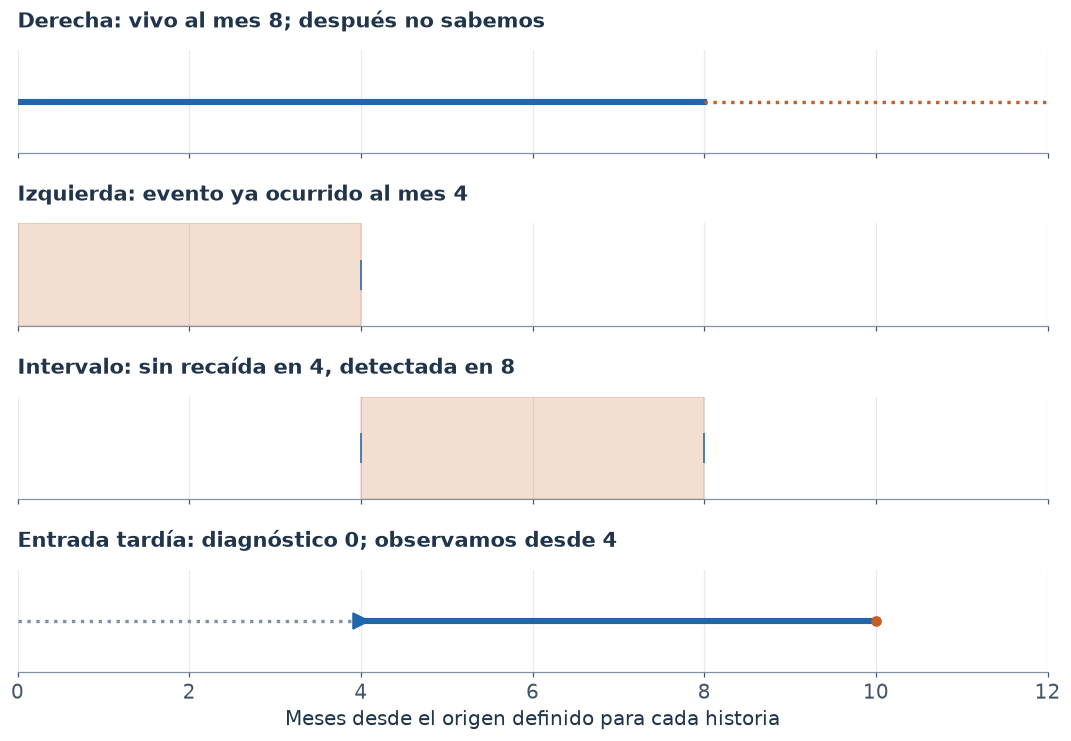

*Figura 03_observacion_esquema. Naranja sombreado: intervalo posible del evento. Entrada tardía es selección y comienzo de observación, no censura izquierda. Para la fila izquierda puede pensarse en seroconversión antes de la primera visita.*

In [17]:
BLOQUE='03-A1'
PDF_REF='B.2'
contexto('Tipos de observación incompleta','Evento clínico especificado en cada fila','meses',
         'Cuatro historias hipotéticas para reconocer el tipo de información')
fig,axs=plt.subplots(4,1,figsize=(10,7),sharex=True)
labels=['Derecha: vivo al mes 8; después no sabemos','Izquierda: evento ya ocurrido al mes 4',
        'Intervalo: sin recaída en 4, detectada en 8','Entrada tardía: diagnóstico 0; observamos desde 4']
for ax,label in zip(axs,labels):
    ax.set(ylim=(-.5,.5),yticks=[],xlim=(0,12));ax.set_title(label,loc='left',fontsize=12)
    ax.spines['left'].set_visible(False)
axs[0].plot([0,8],[0,0],color=AZUL,lw=4);axs[0].plot([8,12],[0,0],color=NARANJA,ls=':')
axs[1].axvspan(0,4,color=NARANJA,alpha=.2);axs[1].plot(4,0,'|',ms=20,color=AZUL)
axs[2].axvspan(4,8,color=NARANJA,alpha=.2);axs[2].plot([4,8],[0,0],'|',ms=20,color=AZUL)
axs[3].plot([0,4],[0,0],color='#8091A5',ls=':');axs[3].plot([4,10],[0,0],color=AZUL,lw=4)
axs[3].plot(4,0,'>',color=AZUL,ms=10);axs[3].plot(10,0,'o',color=NARANJA)
axs[-1].set_xlabel('Meses desde el origen definido para cada historia')
fig.tight_layout();figura(fig,'03_observacion_esquema','Naranja sombreado: intervalo posible del evento. Entrada tardía es selección y comienzo de observación, no censura izquierda. Para la fila izquierda puede pensarse en seroconversión antes de la primera visita.')

### 👀 Dónde mirar e interpretar
Un evento detectado entre visitas tiene un intervalo, no una fecha exacta inventada.

### 📝 Tu respuesta
¿Es inocuo usar siempre el punto medio?

Escribe aquí: …

<details><summary>Orientación: abre después de responder</summary>

No; puede introducir sesgo. Hay métodos específicos para información por intervalos.

</details>

<a id="03-A2"></a>
## 🌱 Opcional · 03-A2 · Ampliación: corte de calendario, análisis intermedio y multiplicidad

**Puente al PDF:** [apartado B.3](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-B-3). En Colab puedes localizarlo por su número.

**Pregunta clínica.** ¿Qué información existe en un corte de calendario?

**Antes de ejecutar.** Una persona todavía no incorporada no aporta futuro al análisis.

**Acción.** Pulsa ▶ en las celdas siguientes. No necesitas cambiar el código.

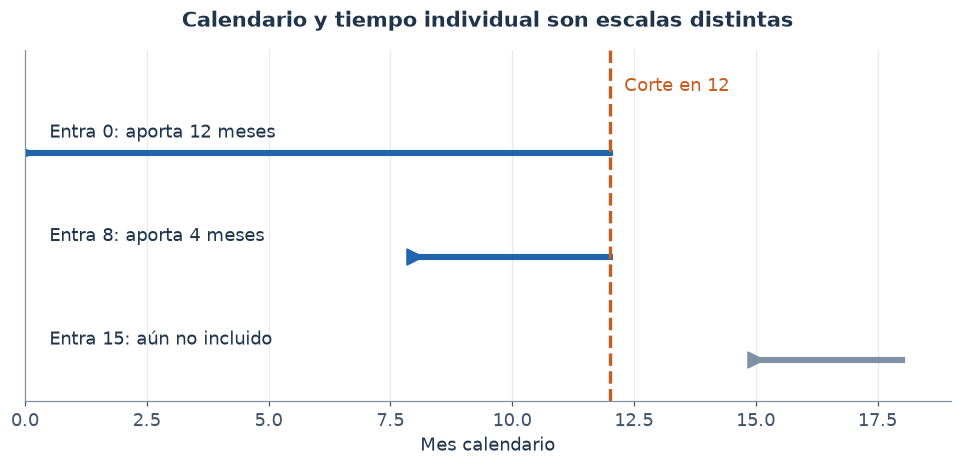

*Figura 03_calendario_esquema. Historias hipotéticas sin muerte antes del corte. Las dos personas incluidas se censuran administrativamente; la incorporación futura se excluye.*

In [18]:
BLOQUE='03-A2'
PDF_REF='B.3'
contexto('Corte del calendario','Muerte desde inclusión','meses de calendario',
         'Tres historias hipotéticas para ilustrar el corte; independientes del ensayo simulado de 500')
fig,ax=plt.subplots(figsize=(9,4.5))
for y,start,end,label in [(2,0,12,'Entra 0: aporta 12 meses'),(1,8,12,'Entra 8: aporta 4 meses'),(0,15,18,'Entra 15: aún no incluido')]:
    ax.plot([start,end],[y,y],lw=4,color=AZUL if start<12 else '#8091A5')
    ax.plot(start,y,'>',color=AZUL if start<12 else '#8091A5',ms=10)
    ax.text(.5,y+.15,label,fontsize=11)
ax.axvline(12,color=NARANJA,ls='--');ax.text(12.3,2.6,'Corte en 12',color=NARANJA)
ax.set(xlim=(0,19),ylim=(-.4,3),yticks=[],xlabel='Mes calendario',title='Calendario y tiempo individual son escalas distintas')
fig.tight_layout();figura(fig,'03_calendario_esquema','Historias hipotéticas sin muerte antes del corte. Las dos personas incluidas se censuran administrativamente; la incorporación futura se excluye.')

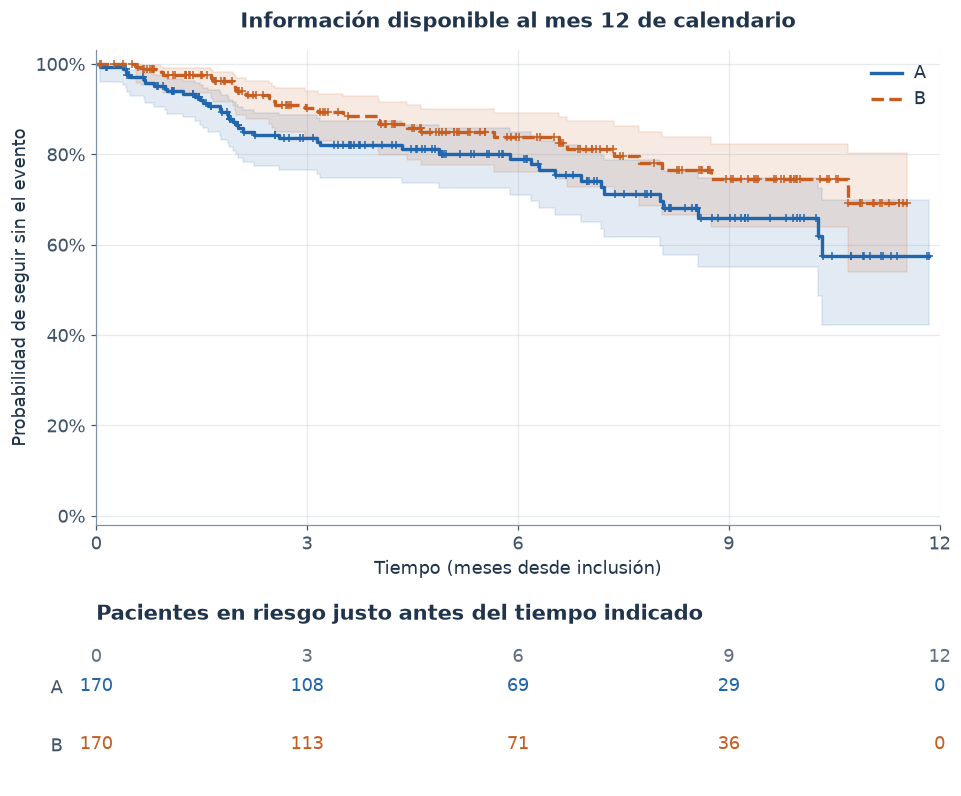

*Figura 03_corte_12. Curvas recalculadas tras censurar en el corte; no se usan eventos posteriores ni pacientes aún no incluidos.*

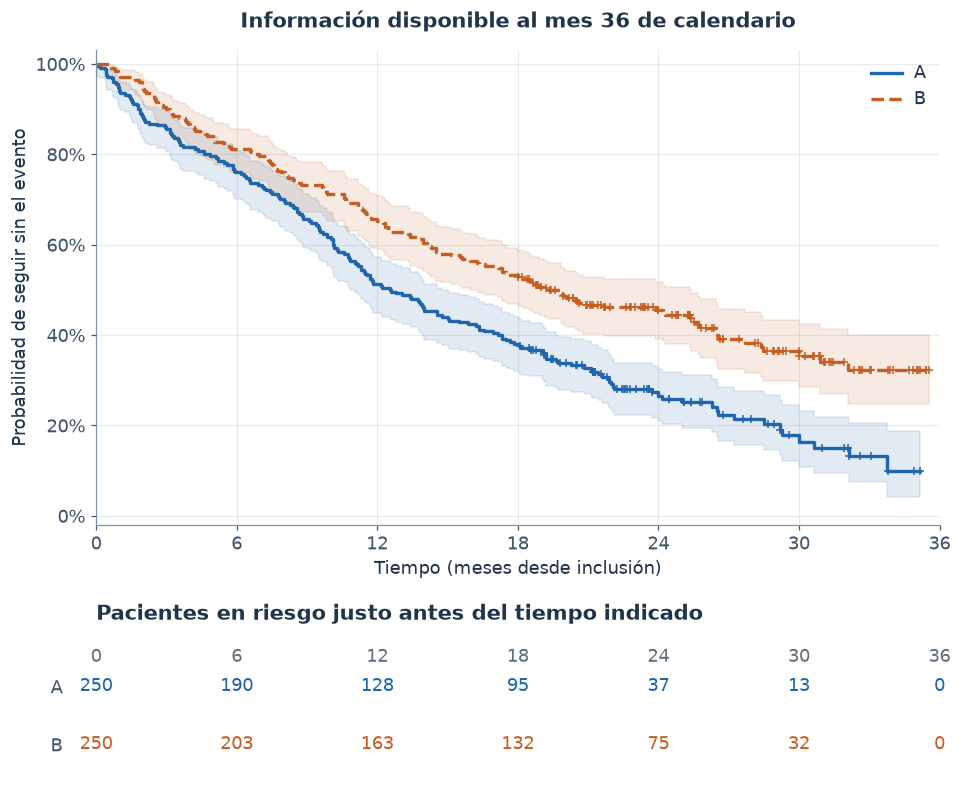

*Figura 03_corte_36. Curvas recalculadas tras censurar en el corte; no se usan eventos posteriores ni pacientes aún no incluidos.*

Corte calendario,Incluidos,Eventos disponibles,p log-rank,"Cruza umbral docente 0,025"
12,340,69,"0,070",False
36,500,340,"< 0,001",True


*Tabla 03_intermedios. Los dos cortes se muestran para docencia; no se ha detenido realmente el ensayo simulado ni aplicado una regla clínica automática.*

In [19]:
BLOQUE='03-A2'
PDF_REF='B.3'
contexto('Dos cortes de ensayo simulado','Muerte desde inclusión','meses; cortes en calendario','Simulación con reclutamiento escalonado y dos análisis planificados',semilla=1801,N=500,alpha_por_analisis=.025)
rng=np.random.default_rng(1801);entrada=rng.uniform(0,18,500);g=np.where(np.arange(500)%2,'B','A');real=rng.exponential(1/np.where(g=='B',.035,.05))
base=pd.DataFrame({'id':range(500),'entrada':entrada,'grupo':g,'muerte_desde_entrada':real});datos(base,'03_datos_ensayo_calendario')
resultados=[]
for corte in [12,36]:
    d=base.loc[base.entrada<=corte].copy();disponible=corte-d.entrada
    d['tiempo']=np.minimum(d.muerte_desde_entrada,disponible);d['evento']=(d.muerte_desde_entrada<=disponible).astype(int)
    assert (d.tiempo+d.entrada<=corte+1e-9).all()
    a=d.loc[d.grupo.eq('A')];c=d.loc[d.grupo.eq('B')];lr=logrank_test(a.tiempo,c.tiempo,a.evento,c.evento)
    resultados.append({'Corte calendario':corte,'Incluidos':len(d),'Eventos disponibles':int(d.evento.sum()),'p log-rank':lr.p_value,
        'Cruza umbral docente 0,025':bool(lr.p_value<.025)})
    fig,_=km_grupos(d,f'Información disponible al mes {corte} de calendario','meses desde inclusión',
        horizonte=corte,ticks=np.arange(0,corte+1,3 if corte==12 else 6))
    figura(fig,f'03_corte_{corte}','Curvas recalculadas tras censurar en el corte; no se usan eventos posteriores ni pacientes aún no incluidos.')
    datos(d,f'03_datos_corte_{corte}')
tabla(pd.DataFrame(resultados),'03_intermedios','Los dos cortes se muestran para docencia; no se ha detenido realmente el ensayo simulado ni aplicado una regla clínica automática.')

### 👀 Dónde mirar e interpretar
Cada corte recalcula inclusión, tiempo y evento; no es una línea vertical en una curva futura completa.

### 📝 Tu respuesta
¿Dos análisis al mismo umbral mantienen el errorglobal?

Escribe aquí: …

<details><summary>Orientación: abre después de responder</summary>

No necesariamente. El protocolo debe considerar multiplicidad y reglas de parada, además de seguridad y madurez.

</details>

<a id="03-A3"></a>
## 🌱 Opcional · 03-A3 · Ampliación: error tipo I/II y potencia en simulaciones

**Puente al PDF:** [apartado B.4](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-B-4). En Colab puedes localizarlo por su número.

**Pregunta clínica.** ¿Qué enseña conocer la verdad del simulador?

**Antes de ejecutar.** Dos escenarios prefijados; no escoger semillas por suresultado.

**Acción.** Pulsa ▶ en las celdas siguientes. No necesitas cambiar el código.

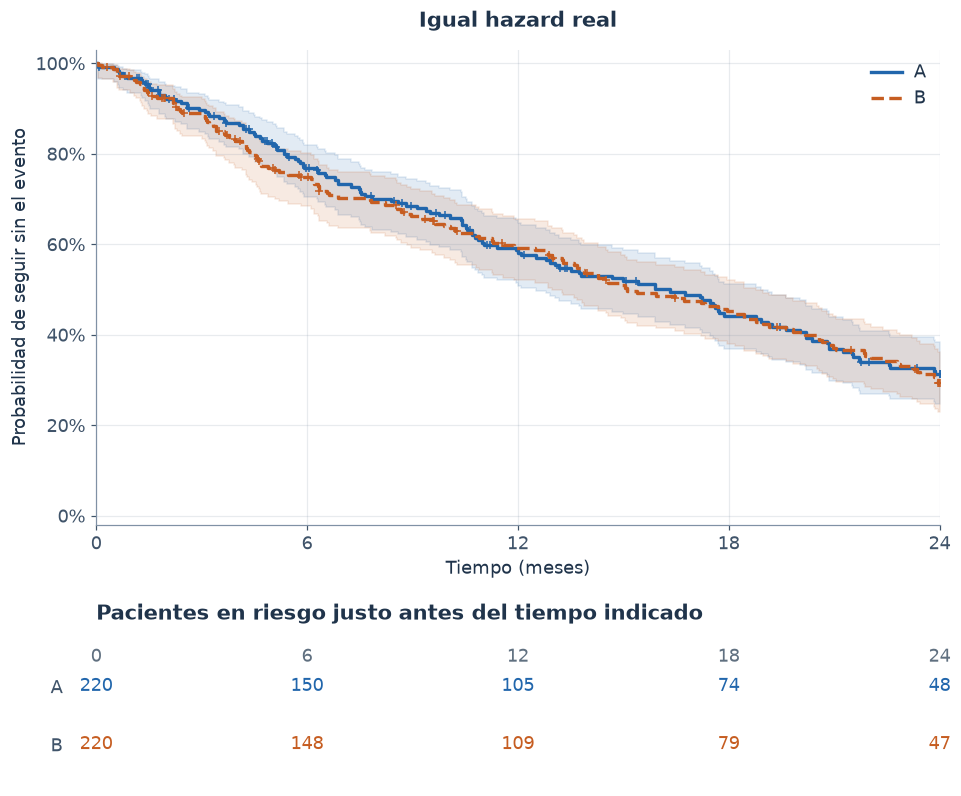

*Figura 03_escenario_1101. Tratamientos ficticios; IC95 %, censuras y números en riesgo. Los efectos se fijaron antes de simular.*

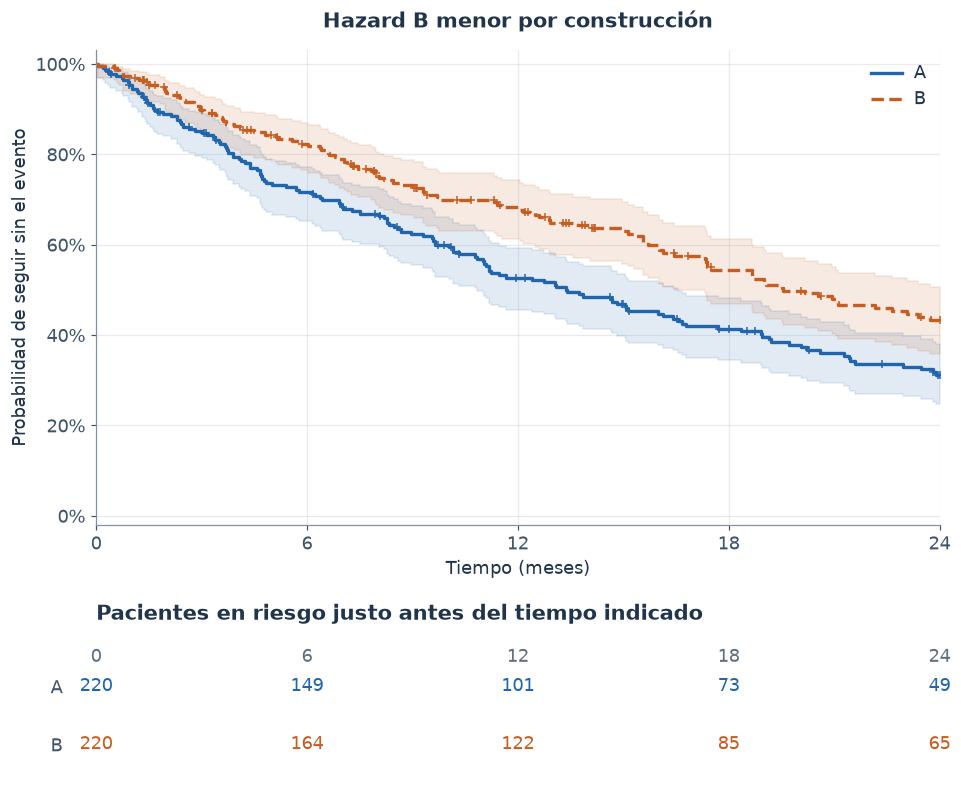

*Figura 03_escenario_1102. Tratamientos ficticios; IC95 %, censuras y números en riesgo. Los efectos se fijaron antes de simular.*

Escenario,HR real,HR estimado,IC95 inferior,IC95 superior,p log-rank,Lectura p
Igual hazard real,1.000,1.046,0.821,1.332,"0,717","p = 0,717"
Hazard B menor por construcción,0.650,0.686,0.531,0.886,"0,004","p = 0,004"


*Tabla 03_escenarios_resultados. Distinción entre mecanismo conocido de simulación y resultados de una muestra. No se cambia la semilla para obtener un p deseado.*

In [20]:
BLOQUE='03-A3'
PDF_REF='B.4'
resultados=[];escenarios={}
for nombre,seed,hb in [('Igual hazard real',1101,.05),('Hazard B menor por construcción',1102,.0325)]:
    d=simular(seed,hB=hb);escenarios[nombre]=d
    contexto(nombre,'Muerte después de cirugía','meses','Simulación exponencial con censura independiente',semilla=seed,N=len(d),hazard_A=.05,hazard_B=hb)
    datos(d,'03_datos_'+str(seed))
    fig,ks=km_grupos(d,nombre,'meses',ticks=[0,6,12,18,24]);figura(fig,'03_escenario_'+str(seed),'Tratamientos ficticios; IC95 %, censuras y números en riesgo. Los efectos se fijaron antes de simular.')
    a=d.loc[d.grupo.eq('A')];bb=d.loc[d.grupo.eq('B')];lr=logrank_test(a.tiempo,bb.tiempo,a.evento,bb.evento)
    dd=d.assign(B=d.grupo.eq('B').astype(int));m=CoxPHFitter().fit(dd[['tiempo','evento','B']],'tiempo','evento');s=m.summary.loc['B']
    resultados.append({'Escenario':nombre,'HR real':hb/.05,'HR estimado':s['exp(coef)'],'IC95 inferior':s['exp(coef) lower 95%'],
        'IC95 superior':s['exp(coef) upper 95%'],'p log-rank':lr.p_value,'Lectura p':ptexto(lr.p_value)})
contexto('Comparación de dos mecanismos simulados','Muerte después de cirugía','meses','Dos simulaciones exponenciales independientes',semillas=[1101,1102],N_por_escenario=440)
tabla(pd.DataFrame(resultados),'03_escenarios_resultados','Distinción entre mecanismo conocido de simulación y resultados de una muestra. No se cambia la semilla para obtener un p deseado.')

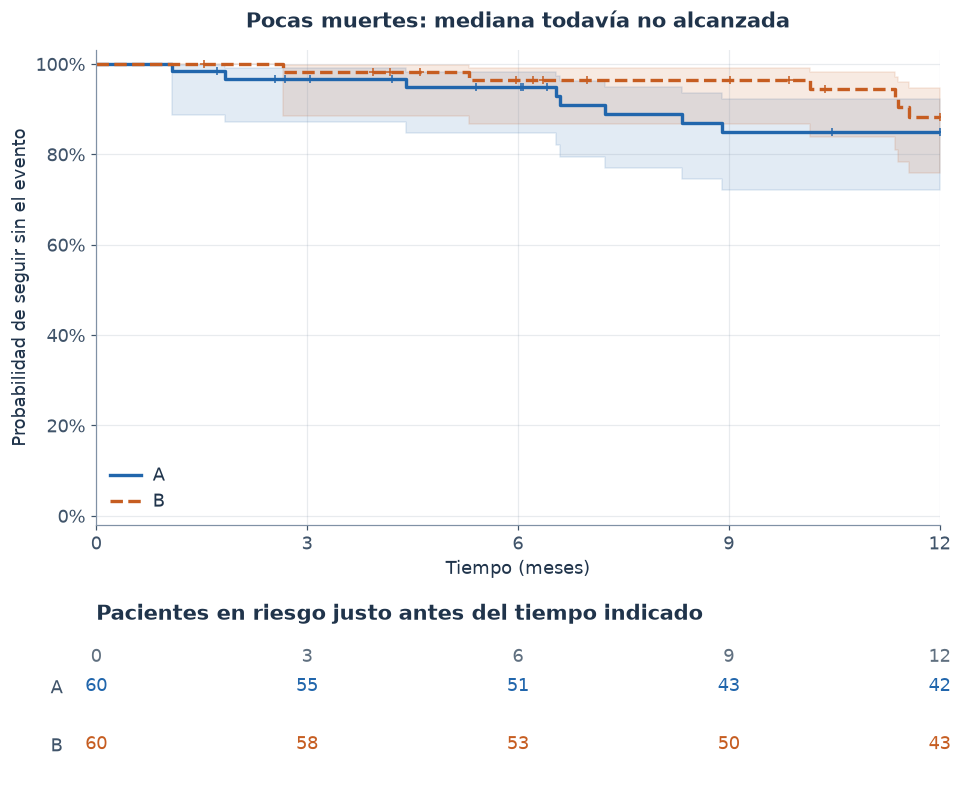

*Figura 03_mediana_no_alcanzada. La banda y la tabla de riesgo importan tanto como la altura. No se extrapola después de 12 meses.*

Grupo,N,Eventos,Censuras,Horizonte,S(t),IC95 inferior,IC95 superior,Mediana
A,60,8,52,12,0.849,0.721,0.922,No alcanzada
B,60,6,54,12,0.883,0.758,0.946,No alcanzada


*Tabla 03_resumen_corto. Si S no alcanza 0,5, la mediana no puede estimarse con este seguimiento.*

In [21]:
BLOQUE='03-A3'
PDF_REF='B.4'
contexto('Seguimiento corto','Muerte después de cirugía','meses','Simulación de hazard bajo y corte a 12 meses',semilla=1301)
corto=simular(1301,n=60,hA=.012,hB=.012,corte=12)
fig,ksc=km_grupos(corto,'Pocas muertes: mediana todavía no alcanzada','meses',ticks=[0,3,6,9,12]);figura(fig,'03_mediana_no_alcanzada','La banda y la tabla de riesgo importan tanto como la altura. No se extrapola después de 12 meses.')
tabla(resumen_km(ksc,12),'03_resumen_corto','Si S no alcanza 0,5, la mediana no puede estimarse con este seguimiento.')
datos(corto,'03_datos_corto')

### 👀 Dónde mirar e interpretar
Un resultado de una réplica no estima potencia ni tasa de error. Mediana no alcanzada no demuestra curación.

### 📝 Tu respuesta
¿Unp alto demuestra que ambos efectos sean iguales?

Escribe aquí: …

<details><summary>Orientación: abre después de responder</summary>

No. Ni unp pequeño mide relevancia clínica. Para potencia/error se necesitan repeticiones y un diseño definido.

</details>

## ▶ Guardar figuras y tablas
Ejecuta esta última celda. Se preparará un ZIP con PDF/SVG vectoriales, PNG de 300 ppp, tablas CSV/LaTeX/HTML y procedencia. Guarda también tu copia del notebook con las respuestas.

In [22]:
cerrar()

Práctica completada: 45 recursos preparados. Guarda tu copia con las respuestas.


E:\OneDrive\UNIR\TEMAS HERRAMIENTAS AVANZADAS\Revision\reestructuracion_supervivencia_20260920\trabajo\notebooks\RecursosSupervivencia\SurvivalAnalysis03_recursos.zip

Los recursos están en la carpeta RecursosSupervivencia de esta sesión.
